## Version 1

In [1]:
# %% [markdown]
# # INFO-F-422 Project: EMG-based Hand Pose Estimation (Free Gestures)
#
# **Team:** [Your Team Name/Number]
# **Members:** [Your Names]
#
# This notebook implements baseline, neural network, and ensemble approaches for predicting hand joint angles from sEMG signals using the **freemoves gestures dataset**.

# %%
# Core Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import pickle
from contextlib import contextmanager

# Scikit-learn Modules
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_validate, cross_val_predict
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, make_scorer, r2_score
from sklearn.linear_model import Ridge, Lasso, LinearRegression # Added LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import set_config

# PyTorch Modules
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Configure visualizations and settings
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
set_config(enable_metadata_routing=True) # Enable metadata routing globally
print(f"Scikit-learn metadata routing enabled: {set_config(True)}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using PyTorch device: {device}")

# Define a timing context manager
@contextmanager
def timer(label: str):
    start = time.time(); print(f"{label}..."); yield; end = time.time()
    print(f"{label} done in {end - start:.2f} seconds.\n")

# Define Performance Metrics
def root_mean_squared_error(y_true, y_pred): return np.sqrt(mean_squared_error(y_true, y_pred))
def normalized_mean_squared_error(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    if y_true.shape != y_pred.shape: raise ValueError("Shape mismatch")
    if y_true.ndim == 1: y_true, y_pred = y_true.reshape(-1, 1), y_pred.reshape(-1, 1)
    numerator = np.sum((y_true - y_pred)**2)
    mean_y_true_per_joint = np.mean(y_true, axis=0)
    denominator = np.sum((y_true - mean_y_true_per_joint)**2)
    return np.inf if denominator == 0 and numerator > 1e-9 else (0.0 if denominator == 0 else numerator / denominator)

scorers = {
    'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
    'nmse': make_scorer(normalized_mean_squared_error, greater_is_better=False),
    'r2': make_scorer(r2_score)
}


Scikit-learn metadata routing enabled: None
Using PyTorch device: cpu


In [2]:


# %% [markdown]
# ## 1. Load Data (Free Gestures)
#
# Load the **freemoves** gestures dataset files.

# %%
# File paths for FREEMOVES dataset
X_TRAIN_VAL_PATH = "freemoves_dataset_X.npy"
Y_TRAIN_VAL_PATH = "freemoves_dataset_y.npy"
X_TEST_PATH = "freemoves_testset_X.npy" # Info for competition format

# Load the training/validation data
X_train_val_raw_fm = np.load(X_TRAIN_VAL_PATH)
y_train_val_raw_fm = np.load(Y_TRAIN_VAL_PATH)

# Load the test data structure description
X_test_raw_info_fm = np.load(X_TEST_PATH, mmap_mode='r')

# Print shapes to verify
print("Raw Freemoves Training/Validation Data Shapes:")
print(f"X_train_val_raw_fm: {X_train_val_raw_fm.shape}") # Should be (5, 8, 270000)
print(f"y_train_val_raw_fm: {y_train_val_raw_fm.shape}") # Should be (5, 51, 270000)
print("\nRaw Freemoves Test Data Shape (for info):")
print(f"X_test_raw_info_fm: {X_test_raw_info_fm.shape}") # Should be (5, 308, 8, 500)

# Constants derived from FREEMOVES data
N_SESSIONS_FM = X_train_val_raw_fm.shape[0]
N_ELECTRODES_FM = X_train_val_raw_fm.shape[1]
N_TIME_POINTS_FM = X_train_val_raw_fm.shape[2]
N_JOINTS_FM = y_train_val_raw_fm.shape[1]

# Verify constants (should be 5, 8, 270000, 51)
print(f"\nNumber of Freemoves Training/Validation Sessions: {N_SESSIONS_FM}")
print(f"Number of Electrodes: {N_ELECTRODES_FM}")
print(f"Number of Time Points per Session: {N_TIME_POINTS_FM}")
print(f"Number of Joints: {N_JOINTS_FM}")

assert N_SESSIONS_FM == 5, "Expected 5 sessions for freemoves train/val"
assert N_ELECTRODES_FM == 8, "Expected 8 electrodes"
assert N_JOINTS_FM == 51, "Expected 51 joints"


Raw Freemoves Training/Validation Data Shapes:
X_train_val_raw_fm: (5, 8, 270000)
y_train_val_raw_fm: (5, 51, 270000)

Raw Freemoves Test Data Shape (for info):
X_test_raw_info_fm: (5, 308, 8, 500)

Number of Freemoves Training/Validation Sessions: 5
Number of Electrodes: 8
Number of Time Points per Session: 270000
Number of Joints: 51


In [3]:


# %% [markdown]
# ## 2. Signal Filtering (Optional but Applied)
#
# Applying band-pass filtering (20-450 Hz) and DC offset removal to the raw **freemoves** sEMG data.

# %%
# (Filtering functions butter_bandpass, bandpass_filter are the same)
from scipy.signal import butter, filtfilt
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs; low = lowcut / nyq; high = highcut / nyq
    b, a = butter(order, [low, high], btype='band'); return b, a
def bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data, axis=-1); return y

FS = 1024 # Sampling frequency
LOWCUT = 20
HIGHCUT = 450

with timer("Applying Signal Filtering to Freemoves Data"):
    X_train_val_filtered_fm = np.zeros_like(X_train_val_raw_fm)
    for i in range(N_SESSIONS_FM):
        dc_removed = X_train_val_raw_fm[i] - np.mean(X_train_val_raw_fm[i], axis=-1, keepdims=True)
        X_train_val_filtered_fm[i] = bandpass_filter(dc_removed, LOWCUT, HIGHCUT, FS)

    X_train_val_to_window_fm = X_train_val_filtered_fm
    print("Applied DC offset removal and bandpass filtering to freemoves data.")

Applying Signal Filtering to Freemoves Data...
Applied DC offset removal and bandpass filtering to freemoves data.
Applying Signal Filtering to Freemoves Data done in 3.97 seconds.



In [4]:


# %% [markdown]
# ## 3. Dataset Preparation: Overlapping Windows (Freemoves)
#
# Segment the filtered **freemoves** sEMG and raw joint angle data into overlapping windows.

# %%
# Windowing Parameters (Keep the same settings)
WINDOW_SIZE = 500  # k
OVERLAP_PERCENTAGE = 0.50 # 50% overlap
step = int(WINDOW_SIZE * (1 - OVERLAP_PERCENTAGE))
print(f"Window Size (k): {WINDOW_SIZE}, Overlap: {OVERLAP_PERCENTAGE*100:.0f}%, Step Size: {step}")

# (create_overlapping_windows function definition is the same)
def create_overlapping_windows(X_raw, y_raw, window_size, step):
    n_sessions, n_electrodes, n_timepoints = X_raw.shape
    n_joints = y_raw.shape[1]
    X_windowed_list, y_windowed_list, groups_list = [], [], []
    for session_idx in range(n_sessions):
        session_X = X_raw[session_idx]; session_y = y_raw[session_idx]
        start_indices = np.arange(0, n_timepoints - window_size + 1, step)
        for start_idx in start_indices:
            end_idx = start_idx + window_size
            window_X = session_X[:, start_idx:end_idx]
            target_y = session_y[:, end_idx - 1]
            X_windowed_list.append(window_X); y_windowed_list.append(target_y)
            groups_list.append(session_idx)
        print(f"Freemoves Session {session_idx}: Created {len(start_indices)} windows.")
    return np.stack(X_windowed_list), np.stack(y_windowed_list), np.array(groups_list)


# Create the windowed dataset for FREEMOVES
with timer("Creating overlapping windows for Freemoves"):
    X_windowed_fm, y_windowed_fm, groups_fm = create_overlapping_windows(
        X_train_val_to_window_fm, y_train_val_raw_fm, WINDOW_SIZE, step
    )

print("\nFreemoves Windowed Data Shapes:")
print(f"X_windowed_fm: {X_windowed_fm.shape}") # Expect more windows than guided
print(f"y_windowed_fm: {y_windowed_fm.shape}")
print(f"groups_fm: {groups_fm.shape}")
print(f"Unique groups_fm (sessions): {np.unique(groups_fm)}")


Window Size (k): 500, Overlap: 50%, Step Size: 250
Creating overlapping windows for Freemoves...
Freemoves Session 0: Created 1079 windows.
Freemoves Session 1: Created 1079 windows.
Freemoves Session 2: Created 1079 windows.
Freemoves Session 3: Created 1079 windows.
Freemoves Session 4: Created 1079 windows.
Creating overlapping windows for Freemoves done in 7.32 seconds.


Freemoves Windowed Data Shapes:
X_windowed_fm: (5395, 8, 500)
y_windowed_fm: (5395, 51)
groups_fm: (5395,)
Unique groups_fm (sessions): [0 1 2 3 4]


In [5]:


# %% [markdown]
# ## 4. Data Preprocessing (Features)
#
# `StandardScaler` will be applied after feature extraction within pipelines or CV loops.

# %%
print("Preprocessing Step: StandardScaler will be applied to extracted freemoves features.")


Preprocessing Step: StandardScaler will be applied to extracted freemoves features.


In [6]:


# %% [markdown]
# ## 5. Custom Feature Extractor
#
# The `EMGFeatureExtractor` class remains the same. It will operate on the `X_windowed_fm` data.

# %%
# (EMGFeatureExtractor class definition is identical)
class EMGFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, zc_threshold=1e-5, ssc_threshold=1e-5, selected_features=None):
        self.zc_threshold = zc_threshold; self.ssc_threshold = ssc_threshold
        self.all_feature_names = ['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR', 'WL', 'SSC']
        if selected_features is None: self.selected_features = self.all_feature_names
        else:
            if not all(f in self.all_feature_names for f in selected_features): raise ValueError("Invalid features.")
            self.selected_features = selected_features
    def fit(self, X, y=None): return self
    def transform(self, X):
        n_windows, n_electrodes, window_size = X.shape; n_selected = len(self.selected_features)
        features = np.zeros((n_windows, n_electrodes * n_selected))
        for i in range(n_windows):
            window_features = []
            for j in range(n_electrodes):
                channel_data = X[i, j, :]; channel_features = []
                mav = np.mean(np.abs(channel_data)); rms = np.sqrt(np.mean(channel_data**2))
                var = np.var(channel_data); std = np.sqrt(var)
                if 'MAV' in self.selected_features: channel_features.append(mav)
                if 'RMS' in self.selected_features: channel_features.append(rms)
                if 'Var' in self.selected_features: channel_features.append(var)
                if 'STD' in self.selected_features: channel_features.append(std)
                if 'ZC' in self.selected_features:
                    zc_count = 0
                    for k in range(window_size - 1):
                        if ((channel_data[k] > self.zc_threshold and channel_data[k+1] < self.zc_threshold) or \
                           (channel_data[k] < self.zc_threshold and channel_data[k+1] > self.zc_threshold)): zc_count += 1
                    channel_features.append(zc_count)
                if 'MPR' in self.selected_features:
                    threshold_mpr = std if std > 1e-9 else 1e-9
                    mpr = np.mean(np.abs(channel_data) > threshold_mpr); channel_features.append(mpr)
                if 'WL' in self.selected_features:
                    wl = np.sum(np.abs(np.diff(channel_data))); channel_features.append(wl)
                if 'SSC' in self.selected_features:
                    diff_sig = np.diff(channel_data); ssc_count = 0
                    for k in range(len(diff_sig) - 1):
                        if ((diff_sig[k] > self.ssc_threshold and diff_sig[k+1] < -self.ssc_threshold) or \
                           (diff_sig[k] < -self.ssc_threshold and diff_sig[k+1] > self.ssc_threshold)): ssc_count += 1
                    channel_features.append(ssc_count)
                window_features.extend(channel_features)
            features[i, :] = window_features
        return np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    def get_feature_names_out(self, input_features=None):
        feature_names = []
        # Use N_ELECTRODES_FM constant defined from freemoves data
        for j in range(N_ELECTRODES_FM):
            for feature_name in self.selected_features:
                feature_names.append(f"Elec{j+1}_{feature_name}")
        return feature_names

# Test the feature extractor on FREEMOVES data
with timer("Testing Feature Extractor on Freemoves Data"):
     feature_extractor_fm = EMGFeatureExtractor()
     X_features_fm = feature_extractor_fm.fit_transform(X_windowed_fm) # Use fm data

print("Freemoves Feature Matrix Shape:")
print(f"X_features_fm: {X_features_fm.shape}")
n_expected_features_fm = N_ELECTRODES_FM * len(feature_extractor_fm.selected_features)
print(f"Expected number of features per window: {n_expected_features_fm}")
assert X_features_fm.shape[1] == n_expected_features_fm, "Feature dimension mismatch!"
feature_names_fm = feature_extractor_fm.get_feature_names_out()
print(f"\nGenerated {len(feature_names_fm)} feature names. Examples: {feature_names_fm[:5]}")


Testing Feature Extractor on Freemoves Data...
Testing Feature Extractor on Freemoves Data done in 142.71 seconds.

Freemoves Feature Matrix Shape:
X_features_fm: (5395, 64)
Expected number of features per window: 64

Generated 64 feature names. Examples: ['Elec1_MAV', 'Elec1_RMS', 'Elec1_Var', 'Elec1_STD', 'Elec1_ZC']


Using GroupKFold with 5 splits for Freemoves.


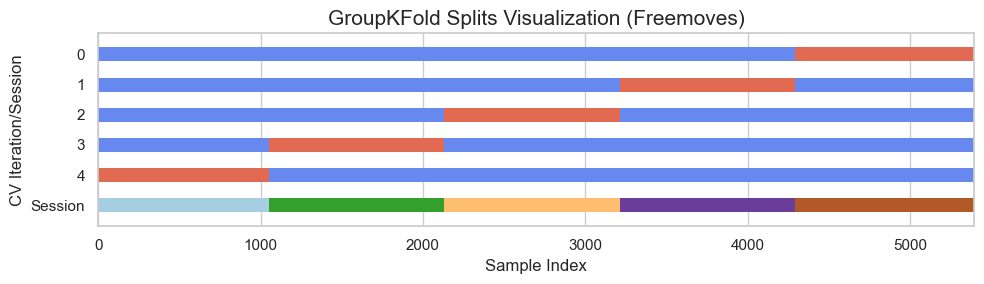

CV Split visualization plot skipped for brevity.


In [ ]:


# %% [markdown]
# ## 6. Cross-Validation Strategy (Freemoves)
#
# Using `GroupKFold` with session IDs from the **freemoves** data (Leave-One-Session-Out, N_SPLITS=5).

# %%
N_SPLITS_FM = N_SESSIONS_FM # Should be 5
cv_strategy_fm = GroupKFold(n_splits=N_SPLITS_FM)
print(f"Using GroupKFold with {N_SPLITS_FM} splits for Freemoves.")

# (plot_cv_indices function definition is the same)
def plot_cv_indices(cv, X, y, group, n_splits, title_suffix=""):
    fig, ax = plt.subplots(1, 1, figsize=(10, 3)); cmap_data=plt.cm.Paired; cmap_cv=plt.cm.coolwarm
    for i, (train_idx, test_idx) in enumerate(cv.split(X, y, group)):
        indices = np.array([np.nan]*len(X)); indices[test_idx]=1; indices[train_idx]=0
        ax.scatter(range(len(indices)), [i+.5]*len(indices), c=indices, marker='_', lw=10, cmap=cmap_cv, vmin=-.2, vmax=1.2)
    ax.scatter(range(len(X)), [i+1.5]*len(X), c=group, marker='_', lw=10, cmap=cmap_data)
    yticklabels = list(range(n_splits)) + ['Session']
    ax.set(yticks=np.arange(n_splits+1)+.5, yticklabels=yticklabels, xlabel='Sample Index', ylabel="CV Iteration/Session", ylim=[n_splits+1.2,-.2], xlim=[0, len(y)])
    ax.set_title(f'GroupKFold Splits Visualization{title_suffix}', fontsize=15); plt.tight_layout(); plt.show()

# Plot for Freemoves setup
plot_cv_indices(cv_strategy_fm, X_features_fm, y_windowed_fm, groups_fm, N_SPLITS_FM, title_suffix=" (Freemoves)")
# print("CV Split visualization plot skipped for brevity.")


In [10]:
# %%
# Evaluate baseline models using Cross-Validation on FREEMOVES data

# !!! SOLUTION 2: Convert data type to float32 to save memory !!!
print(f"Original X_windowed_fm dtype: {X_windowed_fm.dtype}")
print(f"Original y_windowed_fm dtype: {y_windowed_fm.dtype}")
X_windowed_fm = X_windowed_fm.astype(np.float32)
y_windowed_fm = y_windowed_fm.astype(np.float32)
print(f"Converted X_windowed_fm dtype: {X_windowed_fm.dtype}")
print(f"Converted y_windowed_fm dtype: {y_windowed_fm.dtype}")


print("--- Evaluating Baseline Models on Freemoves Data ---")
for model_name, model in baseline_models_to_evaluate_fm.items():
    with timer(f"Cross-validating {model_name} (Freemoves)"):
        pipeline_fm = Pipeline([
            ('feature_extraction', EMGFeatureExtractor()), # Use the same feature extractor class
            ('scaling', StandardScaler()),
            ('regression', model)
        ])

        # Use FREEMOVES data and CV strategy
        scores_fm = cross_validate(
            pipeline_fm,
            X_windowed_fm,         # Freemoves windowed EMG (now float32)
            y_windowed_fm,         # Freemoves targets (now float32)
            cv=cv_strategy_fm,     # Freemoves CV splitter
            scoring=scorers,
            # !!! SOLUTION 1: Reduce n_jobs !!!
            n_jobs=1,              # Start with 1 (sequential), increase later if memory allows
            return_train_score=False,
            params={'groups': groups_fm} # Freemoves groups
        )
        all_cv_results_fm[model_name] = scores_fm

# (Rest of the cell for displaying results remains the same)
# %%
# Display Freemoves Baseline CV Results
print("\nFreemoves Baseline Cross-Validation Performance Results:")
for model_name, scores in all_cv_results_fm.items():
     if model_name in baseline_models_to_evaluate_fm:
        mean_rmse = -np.mean(scores['test_rmse']); std_rmse = np.std(scores['test_rmse'])
        mean_nmse = -np.mean(scores['test_nmse']); std_nmse = np.std(scores['test_nmse'])
        mean_r2 = np.mean(scores['test_r2']); std_r2 = np.std(scores['test_r2'])
        fit_time = np.mean(scores['fit_time']); score_time = np.mean(scores['score_time'])
        print(f"\n--- {model_name} (Freemoves) ---")
        print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
        print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
        print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
        print(f"  Avg Fit Time: {fit_time:.2f}s")
        results_summary_list_fm.append({'Model': model_name, 'Type': 'Baseline',
            'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse,
            'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time})

results_df_fm = pd.DataFrame(results_summary_list_fm)
print("\n--- Freemoves Baseline Summary Table ---")
print(results_df_fm.to_string(index=False, float_format="%.4f"))
# Expect RMSE/NMSE to be higher than for guided gestures


Original X_windowed_fm dtype: float64
Original y_windowed_fm dtype: float64
Converted X_windowed_fm dtype: float32
Converted y_windowed_fm dtype: float32
--- Evaluating Baseline Models on Freemoves Data ---
Cross-validating Ridge (Freemoves)...
Cross-validating Ridge (Freemoves) done in 492.66 seconds.

Cross-validating Lasso (Freemoves)...
Cross-validating Lasso (Freemoves) done in 610.30 seconds.

Cross-validating RandomForest (Freemoves)...
Cross-validating RandomForest (Freemoves) done in 446.64 seconds.


Freemoves Baseline Cross-Validation Performance Results:

--- Ridge (Freemoves) ---
  RMSE: 10.9217 +/- 1.2949
  NMSE: 0.8488 +/- 0.1424
  R2 Score: 0.0037 +/- 0.1426
  Avg Fit Time: 71.63s

--- Lasso (Freemoves) ---
  RMSE: 10.8860 +/- 1.2807
  NMSE: 0.8426 +/- 0.1357
  R2 Score: 0.0063 +/- 0.1266
  Avg Fit Time: 96.40s

--- RandomForest (Freemoves) ---
  RMSE: 10.5901 +/- 1.8486
  NMSE: 0.7922 +/- 0.1680
  R2 Score: 0.0637 +/- 0.1808
  Avg Fit Time: 67.87s

--- Freemoves Baseli

Extracting & Scaling Freemoves features for Analysis...
Shape of Freemoves features for analysis: (5395, 64)
Extracting & Scaling Freemoves features for Analysis done in 47.47 seconds.

Training RandomForest on Freemoves data for Importance Analysis...
Training RandomForest on Freemoves data for Importance Analysis done in 12.38 seconds.


Freemoves Random Forest Feature Importances (Top 30):
1. Feature: Elec4_WL (0.0586)
2. Feature: Elec4_MAV (0.0525)
3. Feature: Elec8_ZC (0.0427)
4. Feature: Elec4_Var (0.0328)
5. Feature: Elec1_MAV (0.0312)
6. Feature: Elec4_RMS (0.0302)
7. Feature: Elec2_WL (0.0289)
8. Feature: Elec8_SSC (0.0289)
9. Feature: Elec4_STD (0.0264)
10. Feature: Elec1_Var (0.0256)
11. Feature: Elec1_RMS (0.0240)
12. Feature: Elec2_MAV (0.0237)
13. Feature: Elec1_SSC (0.0220)
14. Feature: Elec1_STD (0.0217)
15. Feature: Elec1_WL (0.0183)
16. Feature: Elec6_WL (0.0176)
17. Feature: Elec7_WL (0.0167)
18. Feature: Elec2_STD (0.0153)
19. Feature: Elec5_ZC (0.0138)
20. Feature:

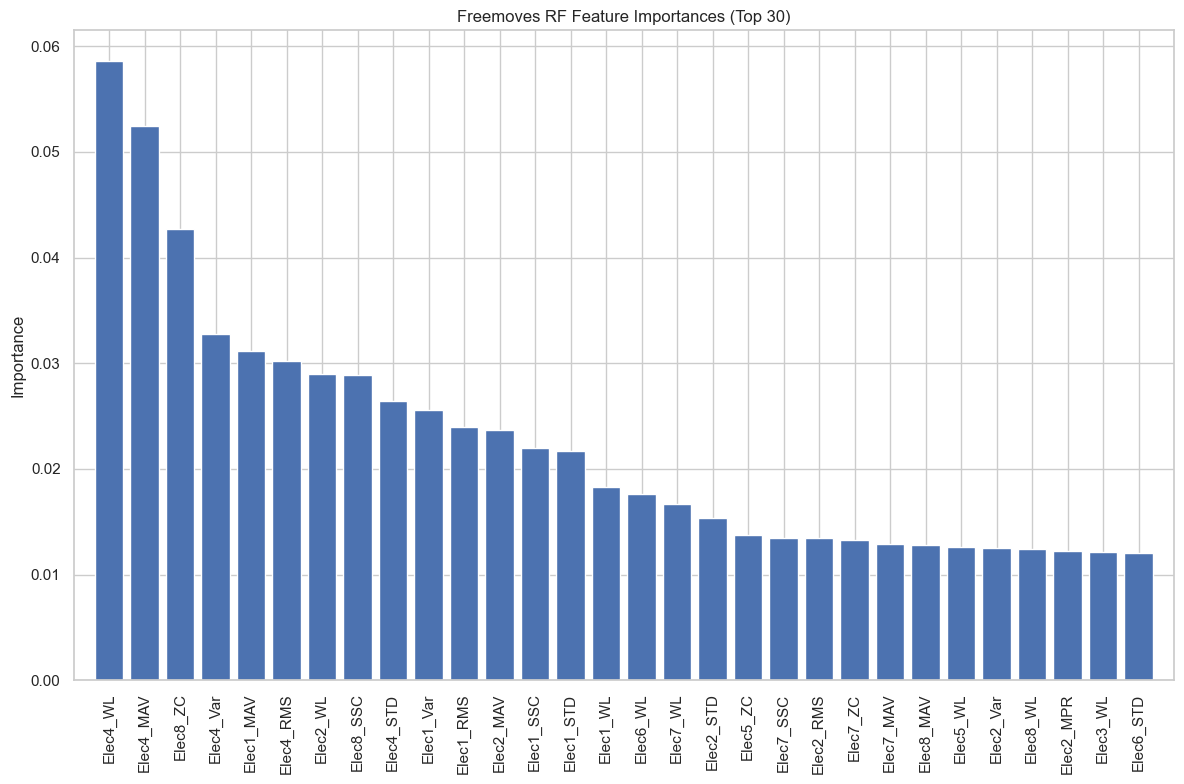


--- Performing SFS on Freemoves Data ---
Fitting SFS (Freemoves)...
Fitting SFS (Freemoves) done in 58.29 seconds.


SFS (Freemoves) selected 25 features out of 64.
Selected Feature Names (Freemoves, first 50):
['Elec1_MAV', 'Elec1_Var', 'Elec1_ZC', 'Elec1_WL', 'Elec2_MAV', 'Elec2_RMS', 'Elec3_MAV', 'Elec3_RMS', 'Elec3_SSC', 'Elec4_MAV', 'Elec4_RMS', 'Elec4_Var', 'Elec4_WL', 'Elec5_MAV', 'Elec5_WL', 'Elec6_STD', 'Elec6_ZC', 'Elec6_WL', 'Elec6_SSC', 'Elec7_ZC', 'Elec7_MPR', 'Elec7_SSC', 'Elec8_ZC', 'Elec8_MPR', 'Elec8_WL']


Counts of selected feature types (Freemoves):
 MAV    5
WL     5
ZC     4
RMS    3
SSC    3
Var    2
MPR    2
STD    1
Name: count, dtype: int64

Counts of selected electrodes (Freemoves):
 Elec1    4
Elec4    4
Elec6    4
Elec3    3
Elec8    3
Elec7    3
Elec2    2
Elec5    2
Name: count, dtype: int64


In [12]:


# %% [markdown]
# ## 8. Feature Importance and Selection (Freemoves)
#
# Analyze RF feature importances and perform SFS on the **freemoves** data.

# %%
# (Analysis pipeline definition is the same)
analysis_pipeline_fm = Pipeline([
    ('feature_extraction', EMGFeatureExtractor()),
    ('scaling', StandardScaler())
])

# Fit and transform the FREEMOVES training data
with timer("Extracting & Scaling Freemoves features for Analysis"):
    X_features_scaled_fm = analysis_pipeline_fm.fit_transform(X_windowed_fm, y_windowed_fm)
    feature_names_fm_analysis = analysis_pipeline_fm.named_steps['feature_extraction'].get_feature_names_out()
    print(f"Shape of Freemoves features for analysis: {X_features_scaled_fm.shape}")

# Train RF on scaled Freemoves features for importance
with timer("Training RandomForest on Freemoves data for Importance Analysis"):
    model_rf_fm.fit(X_features_scaled_fm, y_windowed_fm)

# Get and plot feature importances for Freemoves
importances_fm = model_rf_fm.feature_importances_
indices_fm = np.argsort(importances_fm)[::-1]
print("\nFreemoves Random Forest Feature Importances (Top 30):")
n_top_features = 30
for i in range(min(n_top_features, len(importances_fm))):
    print(f"{i + 1}. Feature: {feature_names_fm_analysis[indices_fm[i]]} ({importances_fm[indices_fm[i]]:.4f})")

plt.figure(figsize=(12, 8)); plt.title("Freemoves RF Feature Importances (Top 30)")
plt.bar(range(min(n_top_features, len(importances_fm))), importances_fm[indices_fm[:n_top_features]], align='center')
plt.xticks(range(min(n_top_features, len(importances_fm))), [feature_names_fm_analysis[i] for i in indices_fm[:n_top_features]], rotation=90)
plt.xlim([-1, min(n_top_features, len(importances_fm))]); plt.ylabel("Importance"); plt.tight_layout(); plt.show()

# %%
# Feature Selection using SFS on Freemoves Data
print("\n--- Performing SFS on Freemoves Data ---")
sfs_fm = SequentialFeatureSelector(
    estimator=Ridge(alpha=1.0),
    n_features_to_select='auto',
    tol=1e-4,
    direction='forward',
    scoring=scorers['rmse'],
    cv=cv_strategy_fm,
    # !!! SOLUTION: Reduce n_jobs for SFS !!!
    n_jobs=1  # Run SFS sequentially to avoid memory/pickling issues
)

with timer("Fitting SFS (Freemoves)"):
    # Now fitting sequentially
    sfs_fm.fit(X_features_scaled_fm, y_windowed_fm, groups=groups_fm)

# Get selected features for Freemoves
selected_feature_indices_fm = sfs_fm.get_support(indices=True)
selected_feature_names_fm = [feature_names_fm_analysis[i] for i in selected_feature_indices_fm]
n_selected_features_fm = len(selected_feature_names_fm)
print(f"\nSFS (Freemoves) selected {n_selected_features_fm} features out of {len(feature_names_fm_analysis)}.")
print("Selected Feature Names (Freemoves, first 50):")
print(selected_feature_names_fm[:50]); print("..." if n_selected_features_fm > 50 else "")
# (Analysis of selected types/electrodes is the same logic, using _fm variables)
if n_selected_features_fm > 0:
    selected_types_fm = [f.split('_')[1] for f in selected_feature_names_fm]
    selected_electrodes_fm = [f.split('_')[0] for f in selected_feature_names_fm]
    print("\nCounts of selected feature types (Freemoves):\n", pd.Series(selected_types_fm).value_counts())
    print("\nCounts of selected electrodes (Freemoves):\n", pd.Series(selected_electrodes_fm).value_counts())


In [13]:


# %% [markdown]
# ## 9. Final Baseline Pipeline with SFS Features (Freemoves - Optional)
#
# Evaluate the best baseline model using only the features selected by SFS on the **freemoves** data.

# %%
if n_selected_features_fm > 0 and n_selected_features_fm < len(feature_names_fm_analysis):
    print("\n--- Evaluating Best Baseline Model with SFS Features (Freemoves) ---")
    if not results_df_fm.empty:
        best_baseline_name_fm = results_df_fm.loc[results_df_fm['RMSE_mean'].idxmin()]['Model']
        print(f"Selected best Freemoves baseline model: {best_baseline_name_fm}")
        best_model_instance_sfs_fm = baseline_models_to_evaluate_fm[best_baseline_name_fm]

        selected_types_only_fm = sorted(list(set( f.split('_', 1)[1] for f in selected_feature_names_fm)))
        print(f"Using {len(selected_types_only_fm)} feature types selected by SFS (Freemoves): {selected_types_only_fm}")

        sfs_pipeline_fm = Pipeline([
            ('feature_extraction', EMGFeatureExtractor(selected_features=selected_types_only_fm)),
            ('scaling', StandardScaler()),
            ('regression', best_model_instance_sfs_fm)]) # Use the corresponding model instance

        with timer(f"CV {best_baseline_name_fm} with {n_selected_features_fm} SFS features (Freemoves)"):
            sfs_scores_fm = cross_validate(sfs_pipeline_fm, X_windowed_fm, y_windowed_fm,
                                           cv=cv_strategy_fm, scoring=scorers, n_jobs=-1,
                                           return_train_score=False, params={'groups': groups_fm})
            model_name_sfs_fm = f"{best_baseline_name_fm}_SFS"
            all_cv_results_fm[model_name_sfs_fm] = sfs_scores_fm

            mean_rmse = -np.mean(sfs_scores_fm['test_rmse']); std_rmse = np.std(sfs_scores_fm['test_rmse'])
            mean_nmse = -np.mean(sfs_scores_fm['test_nmse']); std_nmse = np.std(sfs_scores_fm['test_nmse'])
            mean_r2 = np.mean(sfs_scores_fm['test_r2']); std_r2 = np.std(sfs_scores_fm['test_r2'])
            fit_time = np.mean(sfs_scores_fm['fit_time']); score_time = np.mean(sfs_scores_fm['score_time'])
            print(f"\n--- {model_name_sfs_fm} (Freemoves) ---")
            print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}"); print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
            print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
            results_summary_list_fm.append({'Model': model_name_sfs_fm, 'Type': 'Baseline_SFS', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time})
            results_df_fm = pd.DataFrame(results_summary_list_fm)
    else: print("Skipping SFS pipeline evaluation (Freemoves) as baseline results missing.")
else: print("\nSkipping evaluation with SFS features (Freemoves - SFS selected 0 or all features).")



--- Evaluating Best Baseline Model with SFS Features (Freemoves) ---
Selected best Freemoves baseline model: RandomForest
Using 8 feature types selected by SFS (Freemoves): ['MAV', 'MPR', 'RMS', 'SSC', 'STD', 'Var', 'WL', 'ZC']
CV RandomForest with 25 SFS features (Freemoves)...

--- RandomForest_SFS (Freemoves) ---
  RMSE: 10.5901 +/- 1.8486
  NMSE: 0.7922 +/- 0.1680
  R2 Score: 0.0637 +/- 0.1808
CV RandomForest with 25 SFS features (Freemoves) done in 183.76 seconds.



In [14]:


# %% [markdown]
# ## 10. Sophisticated Approach: Neural Network (Freemoves)
#
# Evaluate the MLP using PyTorch on the **freemoves** data via manual cross-validation.

# %%
# (NN Architecture EMG_NN, train_nn_epoch, evaluate_nn_model functions are identical)
class EMG_NN(nn.Module):
    def __init__(self, n_features, n_joints, hidden_dim1=128, hidden_dim2=64, dropout_p=0.3):
        super(EMG_NN, self).__init__(); self.layer_1 = nn.Linear(n_features, hidden_dim1)
        self.relu1 = nn.ReLU(); self.dropout1 = nn.Dropout(dropout_p); self.layer_2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU(); self.dropout2 = nn.Dropout(dropout_p); self.output_layer = nn.Linear(hidden_dim2, n_joints)
    def forward(self, x):
        x = self.dropout1(self.relu1(self.layer_1(x))); x = self.dropout2(self.relu2(self.layer_2(x)))
        x = self.output_layer(x); return x

def train_nn_epoch(model, dataloader, criterion, optimizer, device):
    model.train(); running_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device); optimizer.zero_grad()
        outputs = model(inputs); loss = criterion(outputs, targets); loss.backward(); optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    return running_loss / len(dataloader.dataset)

def evaluate_nn_model(model, dataloader, criterion, device):
    model.eval(); running_loss = 0.0; all_preds, all_targets = [], []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device); outputs = model(inputs)
            loss = criterion(outputs, targets); running_loss += loss.item() * inputs.size(0)
            all_preds.append(outputs.cpu().numpy()); all_targets.append(targets.cpu().numpy())
    avg_loss = running_loss / len(dataloader.dataset)
    return avg_loss, np.concatenate(all_preds), np.concatenate(all_targets)

# %%
# Manual Cross-Validation Loop for Neural Network on FREEMOVES data

# Hyperparameters (Might need tuning for freemoves, start with same)
N_EPOCHS_FM = 75 # May need more/less for freemoves
BATCH_SIZE_FM = 64
LEARNING_RATE_FM = 0.001
WEIGHT_DECAY_FM = 1e-5

# Use features extracted from freemoves windows
nn_feature_extractor_fm = EMGFeatureExtractor()
nn_cv_scores_fm = {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': []}
print("\n--- Evaluating Neural Network on Freemoves Data (Manual CV) ---")

with timer("Re-extracting Freemoves features for NN CV"):
     X_input_for_nn_cv_fm = nn_feature_extractor_fm.fit_transform(X_windowed_fm)
     n_input_features_fm = X_input_for_nn_cv_fm.shape[1]
     print(f"Freemoves NN Input feature shape: {X_input_for_nn_cv_fm.shape}")

fold_num = 0
for train_idx, val_idx in cv_strategy_fm.split(X_input_for_nn_cv_fm, y_windowed_fm, groups=groups_fm):
    fold_num += 1; print(f"\nStarting Freemoves NN CV Fold {fold_num}/{N_SPLITS_FM}"); start_fold_time = time.time()
    X_train_fold, X_val_fold = X_input_for_nn_cv_fm[train_idx], X_input_for_nn_cv_fm[val_idx]
    y_train_fold, y_val_fold = y_windowed_fm[train_idx], y_windowed_fm[val_idx]
    scaler_fm = StandardScaler(); X_train_fold_scaled = scaler_fm.fit_transform(X_train_fold); X_val_fold_scaled = scaler_fm.transform(X_val_fold)
    train_dataset = TensorDataset(torch.FloatTensor(X_train_fold_scaled), torch.FloatTensor(y_train_fold))
    val_dataset = TensorDataset(torch.FloatTensor(X_val_fold_scaled), torch.FloatTensor(y_val_fold))
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_FM, shuffle=True); val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_FM, shuffle=False)
    model_nn = EMG_NN(n_features=n_input_features_fm, n_joints=N_JOINTS_FM).to(device); criterion = nn.MSELoss()
    optimizer = optim.Adam(model_nn.parameters(), lr=LEARNING_RATE_FM, weight_decay=WEIGHT_DECAY_FM)
    print(f"Fold {fold_num}: Training for {N_EPOCHS_FM} epochs...")
    for epoch in range(N_EPOCHS_FM):
        train_loss = train_nn_epoch(model_nn, train_loader, criterion, optimizer, device)
        if (epoch + 1) % 15 == 0 or epoch == N_EPOCHS_FM - 1: # Print less often maybe
             val_loss_epoch, _, _ = evaluate_nn_model(model_nn, val_loader, criterion, device)
             print(f'  Epoch {epoch+1}/{N_EPOCHS_FM}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss_epoch:.6f}')
    fit_end_time = time.time()
    print(f"Fold {fold_num}: Evaluating on validation set..."); val_loss, y_pred_fold, y_true_fold = evaluate_nn_model(model_nn, val_loader, criterion, device); score_end_time = time.time()
    rmse_fold = root_mean_squared_error(y_true_fold, y_pred_fold); nmse_fold = normalized_mean_squared_error(y_true_fold, y_pred_fold); r2_fold = r2_score(y_true_fold, y_pred_fold)
    nn_cv_scores_fm['test_rmse'].append(-rmse_fold); nn_cv_scores_fm['test_nmse'].append(-nmse_fold); nn_cv_scores_fm['test_r2'].append(r2_fold)
    nn_cv_scores_fm['fit_time'].append(fit_end_time - start_fold_time); nn_cv_scores_fm['score_time'].append(score_end_time - fit_end_time)
    print(f"Fold {fold_num} Metrics (Freemoves): RMSE={rmse_fold:.4f}, NMSE={nmse_fold:.4f}, R2={r2_fold:.4f}")

all_cv_results_fm["NeuralNetwork"] = nn_cv_scores_fm # Store freemoves NN results

# %%
# Add Freemoves NN results to the summary DataFrame
nn_model_name_fm = "NeuralNetwork"
nn_scores_fm = all_cv_results_fm[nn_model_name_fm]
mean_rmse = -np.mean(nn_scores_fm['test_rmse']); std_rmse = np.std(nn_scores_fm['test_rmse'])
mean_nmse = -np.mean(nn_scores_fm['test_nmse']); std_nmse = np.std(nn_scores_fm['test_nmse'])
mean_r2 = np.mean(nn_scores_fm['test_r2']); std_r2 = np.std(nn_scores_fm['test_r2'])
fit_time = np.mean(nn_scores_fm['fit_time']); score_time = np.mean(nn_scores_fm['score_time'])
results_summary_list_fm.append({'Model': nn_model_name_fm, 'Type': 'Sophisticated', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time})
results_df_fm = pd.DataFrame(results_summary_list_fm) # Update df
print("\n--- Freemoves Combined Model Comparison Table (Before Ensembles) ---")
print(results_df_fm.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))



--- Evaluating Neural Network on Freemoves Data (Manual CV) ---
Re-extracting Freemoves features for NN CV...
Freemoves NN Input feature shape: (5395, 64)
Re-extracting Freemoves features for NN CV done in 229.94 seconds.


Starting Freemoves NN CV Fold 1/5
Fold 1: Training for 75 epochs...
  Epoch 15/75, Train Loss: 102.222698, Val Loss: 86.512773
  Epoch 30/75, Train Loss: 94.499618, Val Loss: 87.743432
  Epoch 45/75, Train Loss: 90.709392, Val Loss: 82.721531
  Epoch 60/75, Train Loss: 87.633621, Val Loss: 79.161596
  Epoch 75/75, Train Loss: 84.631115, Val Loss: 77.577510
Fold 1: Evaluating on validation set...
Fold 1 Metrics (Freemoves): RMSE=8.8078, NMSE=0.6972, R2=-4336594.0000

Starting Freemoves NN CV Fold 2/5
Fold 2: Training for 75 epochs...
  Epoch 15/75, Train Loss: 98.818044, Val Loss: 88.475317
  Epoch 30/75, Train Loss: 89.851393, Val Loss: 84.098860
  Epoch 45/75, Train Loss: 87.682512, Val Loss: 82.403199
  Epoch 60/75, Train Loss: 83.063748, Val Loss: 81.419348
  Ep

In [ ]:


# %% [markdown]
# ## 11. Objective 6: Ensembling Strategies (Freemoves)
#
# Implement Averaging and Stacking ensembles using OOF predictions from models trained on **freemoves** data.

# %% [markdown]
# ### 11.1 Generate OOF Predictions (Freemoves)

# %%
oof_predictions_fm = {}

# --- OOF for Scikit-learn Models (Freemoves) ---
print("--- Generating OOF Predictions for Baseline Models (Freemoves) ---")
baseline_pipelines_fm = {}
for model_name, model in baseline_models_to_evaluate_fm.items():
     baseline_pipelines_fm[model_name] = Pipeline([('feature_extraction', EMGFeatureExtractor()), ('scaling', StandardScaler()), ('regression', model)])

for model_name, pipeline in baseline_pipelines_fm.items():
     with timer(f"Generating OOF predictions for {model_name} (Freemoves)"):
          oof_preds = cross_val_predict(pipeline, X_windowed_fm, y_windowed_fm, cv=cv_strategy_fm,
                                        n_jobs=-1, method='predict', params={'groups': groups_fm})
          oof_predictions_fm[model_name] = oof_preds
     print(f"Shape of {model_name} Freemoves OOF predictions: {oof_preds.shape}")

# --- OOF for Neural Network (Freemoves) ---
print("\n--- Generating OOF Predictions for Neural Network (Freemoves) ---")
nn_oof_preds_list_fm = [None] * len(X_input_for_nn_cv_fm)
nn_indices_list_fm = []
fold_num = 0
with timer("Generating OOF predictions for NN (Freemoves, Manual CV)"):
    for train_idx, val_idx in cv_strategy_fm.split(X_input_for_nn_cv_fm, y_windowed_fm, groups=groups_fm):
        fold_num += 1; print(f"  Processing Freemoves NN OOF Fold {fold_num}/{N_SPLITS_FM}")
        X_train_fold, X_val_fold = X_input_for_nn_cv_fm[train_idx], X_input_for_nn_cv_fm[val_idx]
        y_train_fold, y_val_fold = y_windowed_fm[train_idx], y_windowed_fm[val_idx]
        scaler_fm_oof = StandardScaler(); X_train_fold_scaled = scaler_fm_oof.fit_transform(X_train_fold); X_val_fold_scaled = scaler_fm_oof.transform(X_val_fold)
        train_dataset = TensorDataset(torch.FloatTensor(X_train_fold_scaled), torch.FloatTensor(y_train_fold)); val_dataset = TensorDataset(torch.FloatTensor(X_val_fold_scaled), torch.FloatTensor(y_val_fold))
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_FM, shuffle=True); val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_FM, shuffle=False)
        model_nn = EMG_NN(n_features=n_input_features_fm, n_joints=N_JOINTS_FM).to(device); criterion = nn.MSELoss()
        optimizer = optim.Adam(model_nn.parameters(), lr=LEARNING_RATE_FM, weight_decay=WEIGHT_DECAY_FM)
        for epoch in range(N_EPOCHS_FM): # Same number of epochs
            _ = train_nn_epoch(model_nn, train_loader, criterion, optimizer, device)
        _, y_pred_fold, _ = evaluate_nn_model(model_nn, val_loader, criterion, device)
        for i, idx in enumerate(val_idx): nn_oof_preds_list_fm[idx] = y_pred_fold[i]
        nn_indices_list_fm.extend(val_idx.tolist())

oof_predictions_fm["NeuralNetwork"] = np.stack(nn_oof_preds_list_fm)
assert len(nn_indices_list_fm) == len(X_input_for_nn_cv_fm), "NN OOF count mismatch (Freemoves)."
print(f"Shape of Freemoves NN OOF predictions: {oof_predictions_fm['NeuralNetwork'].shape}")


In [ ]:


# %% [markdown]
# ### 11.2 Averaging Ensemble (Freemoves)

# %%
print("\n--- Evaluating Averaging Ensemble (Freemoves) ---")
model_names_for_avg_fm = list(oof_predictions_fm.keys())
print(f"Averaging Freemoves predictions from models: {model_names_for_avg_fm}")
oof_preds_sum_fm = np.sum([oof_predictions_fm[name] for name in model_names_for_avg_fm], axis=0)
oof_preds_avg_fm = oof_preds_sum_fm / len(model_names_for_avg_fm)

avg_rmse_fm = root_mean_squared_error(y_windowed_fm, oof_preds_avg_fm)
avg_nmse_fm = normalized_mean_squared_error(y_windowed_fm, oof_preds_avg_fm)
avg_r2_fm = r2_score(y_windowed_fm, oof_preds_avg_fm)
print(f"\nAveraging Ensemble Performance (Freemoves OOF):")
print(f"  RMSE: {avg_rmse_fm:.4f}, NMSE: {avg_nmse_fm:.4f}, R2 Score: {avg_r2_fm:.4f}")

results_summary_list_fm.append({'Model': 'AverageEnsemble', 'Type': 'Ensemble', 'RMSE_mean': avg_rmse_fm, 'RMSE_std': np.nan, 'NMSE_mean': avg_nmse_fm, 'NMSE_std': np.nan, 'R2_mean': avg_r2_fm, 'R2_std': np.nan, 'FitTime': np.nan})
results_df_fm = pd.DataFrame(results_summary_list_fm)


# %% [markdown]
# ### 11.3 Stacking Ensemble (Freemoves)

# %%
print("\n--- Evaluating Stacking Ensemble (Freemoves) ---")
model_names_for_stacking_fm = list(oof_predictions_fm.keys())
print(f"Stacking Freemoves predictions from models: {model_names_for_stacking_fm}")
X_meta_list_fm = [oof_predictions_fm[name] for name in model_names_for_stacking_fm]
X_meta_fm = np.hstack(X_meta_list_fm)
print(f"Shape of Freemoves Meta-Features (X_meta_fm): {X_meta_fm.shape}")

meta_model_fm = Ridge(alpha=1.0) # Use Ridge meta-learner
print(f"Using Meta-Learner: {meta_model_fm.__class__.__name__}")

with timer(f"Cross-validating Stacking Meta-Learner (Freemoves)"):
     stacking_pipeline_fm = Pipeline([('meta_regression', meta_model_fm)])
     stacking_scores_fm = cross_validate(stacking_pipeline_fm, X_meta_fm, y_windowed_fm,
                                        cv=cv_strategy_fm, scoring=scorers, n_jobs=-1,
                                        return_train_score=False, params={'groups': groups_fm})
     all_cv_results_fm["StackingEnsemble"] = stacking_scores_fm

stacking_model_name_fm = "StackingEnsemble"
mean_rmse = -np.mean(stacking_scores_fm['test_rmse']); std_rmse = np.std(stacking_scores_fm['test_rmse'])
mean_nmse = -np.mean(stacking_scores_fm['test_nmse']); std_nmse = np.std(stacking_scores_fm['test_nmse'])
mean_r2 = np.mean(stacking_scores_fm['test_r2']); std_r2 = np.std(stacking_scores_fm['test_r2'])
fit_time = np.mean(stacking_scores_fm['fit_time'])
print(f"\nStacking Ensemble Performance (Freemoves, Cross-Validated):")
print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}"); print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}"); print(f"  Avg Meta Fit Time: {fit_time:.2f}s")

results_summary_list_fm.append({'Model': stacking_model_name_fm, 'Type': 'Ensemble', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time})
results_df_fm = pd.DataFrame(results_summary_list_fm)


# %% [markdown]
# ### 11.4 Meta-Learner Contribution Analysis (Stacking - Freemoves)

# %%
print("\n--- Stacking Meta-Learner Contribution Analysis (Freemoves) ---")
final_meta_pipeline_fm = Pipeline([('meta_regression', Ridge(alpha=1.0))])
final_meta_pipeline_fm.fit(X_meta_fm, y_windowed_fm)
meta_regressor_trained_fm = final_meta_pipeline_fm.named_steps['meta_regression']
coefficients_fm = meta_regressor_trained_fm.coef_
print(f"Shape of Freemoves meta-learner coefficients: {coefficients_fm.shape}")

n_models_fm = len(model_names_for_stacking_fm); n_joints_fm = y_windowed_fm.shape[1]
avg_coef_magnitudes_fm = {}
for i, model_name in enumerate(model_names_for_stacking_fm):
    start_col = i * n_joints_fm; end_col = (i + 1) * n_joints_fm
    model_coefs = coefficients_fm[:, start_col:end_col]
    avg_mag = np.mean(np.abs(model_coefs))
    avg_coef_magnitudes_fm[model_name] = avg_mag
    print(f"  Avg. Abs. Coef Magnitude for {model_name} (Freemoves): {avg_mag:.4f}")

coef_mag_series_fm = pd.Series(avg_coef_magnitudes_fm).sort_values(ascending=False)
print("\nRelative Contribution (Freemoves) based on Avg. Abs. Coefficient Magnitude:")
print(coef_mag_series_fm)

plt.figure(figsize=(8, 4)); coef_mag_series_fm.plot(kind='bar')
plt.title('Stacking Meta-Learner: Base Model Contribution (Freemoves)')
plt.ylabel('Average Absolute Coefficient Magnitude'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


# %% [markdown]
# **Discussion of Ensembling Results (Freemoves):**
# - Compare ensemble performance to base models *for the freemoves data*. Is the relative performance similar to the guided gestures results, or did the complexity of freemoves change which models/ensembles worked best?
# - Discuss bias-variance specifically in the context of the likely higher variance (more complex movements) in the freemoves data. Did ensembling provide a more significant improvement here?
# - Analyze the meta-learner contributions. Did the importance of base models change compared to the guided gestures analysis?

# %% [markdown]
# ## 12. Combined Model Comparison Table (Freemoves - Final)
#
# Display the final table including all results for the **freemoves** dataset.

# %%
print("\n--- Final Combined Model Comparison Table (Freemoves) ---")
results_df_fm = pd.DataFrame(results_summary_list_fm) # Ensure updated
print(results_df_fm.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))


# %% [markdown]
# ## 13. Final Model Selection and Training (Freemoves)
#
# Select the best model/ensemble based on **freemoves** CV results and train it on the full **freemoves** training data.

# %%
# Choose the best model based on FREEMOVES cross-validation results
results_df_fm = pd.DataFrame(results_summary_list_fm) # Ensure it's the latest
best_overall_model_name_fm = results_df_fm.loc[results_df_fm['RMSE_mean'].idxmin()]['Model']
print(f"\nSelected best overall model/ensemble for Freemoves based on CV RMSE: {best_overall_model_name_fm}")

# Prepare data and train the final selected model/ensemble strategy for FREEMOVES
final_trained_entity_fm = None # Store the final trained object(s) for freemoves

# --- Training Logic for FREEMOVES ---
if best_overall_model_name_fm == "AverageEnsemble":
    print("\nPreparing Average Ensemble for Freemoves test prediction...")
    trained_base_models_fm = {}
    # Train Scikit-learn models on full freemoves data
    for model_name, pipeline in baseline_pipelines_fm.items(): # Use fm pipelines/models
         with timer(f"Training final {model_name} (Freemoves) for averaging"):
              pipeline.fit(X_windowed_fm, y_windowed_fm) # Use fm data
              trained_base_models_fm[model_name] = pipeline
    # Train NN on full freemoves data
    print("Training final NN (Freemoves) for averaging...")
    final_scaler_nn_avg_fm = StandardScaler().fit(X_input_for_nn_cv_fm) # Fit scaler on all fm features
    X_nn_scaled_final_avg_fm = final_scaler_nn_avg_fm.transform(X_input_for_nn_cv_fm)
    final_dataset_avg_fm = TensorDataset(torch.FloatTensor(X_nn_scaled_final_avg_fm), torch.FloatTensor(y_windowed_fm))
    final_train_loader_avg_fm = DataLoader(final_dataset_avg_fm, batch_size=128, shuffle=True)
    final_model_nn_avg_fm = EMG_NN(n_features=n_input_features_fm, n_joints=N_JOINTS_FM).to(device)
    final_criterion_avg_fm = nn.MSELoss(); final_optimizer_avg_fm = optim.Adam(final_model_nn_avg_fm.parameters(), lr=LEARNING_RATE_FM, weight_decay=WEIGHT_DECAY_FM)
    FINAL_N_EPOCHS_AVG_FM = N_EPOCHS_FM
    with timer(f"Training final NN for averaging (Freemoves, {FINAL_N_EPOCHS_AVG_FM} epochs)"):
        for epoch in range(FINAL_N_EPOCHS_AVG_FM): _ = train_nn_epoch(final_model_nn_avg_fm, final_train_loader_avg_fm, final_criterion_avg_fm, final_optimizer_avg_fm, device)
    trained_base_models_fm['NeuralNetwork'] = {'model': final_model_nn_avg_fm, 'scaler': final_scaler_nn_avg_fm}
    final_trained_entity_fm = {'type': 'average', 'base_models': trained_base_models_fm, 'feature_extractor': EMGFeatureExtractor()}
    print("Stored trained base models (Freemoves) needed for Averaging Ensemble.")

elif best_overall_model_name_fm == "StackingEnsemble":
    print("\nPreparing Stacking Ensemble for Freemoves test prediction...")
    # 1. Need OOF predictions (X_meta_fm) to train final meta-learner
    # 2. Train final meta-learner on all OOF freemoves predictions
    final_meta_pipeline_stack_fm = Pipeline([('meta_regression', Ridge(alpha=1.0))])
    with timer("Training final Stacking meta-learner (Freemoves)"):
         final_meta_pipeline_stack_fm.fit(X_meta_fm, y_windowed_fm)
    # 3. Train all base models on full freemoves data
    trained_base_models_stack_fm = {}
    for model_name, pipeline in baseline_pipelines_fm.items():
         with timer(f"Training final {model_name} (Freemoves) for stacking base"):
              pipeline.fit(X_windowed_fm, y_windowed_fm); trained_base_models_stack_fm[model_name] = pipeline
    print("Training final NN (Freemoves) for stacking base...")
    final_scaler_nn_stack_fm = StandardScaler().fit(X_input_for_nn_cv_fm)
    X_nn_scaled_final_stack_fm = final_scaler_nn_stack_fm.transform(X_input_for_nn_cv_fm)
    final_dataset_stack_fm = TensorDataset(torch.FloatTensor(X_nn_scaled_final_stack_fm), torch.FloatTensor(y_windowed_fm))
    final_train_loader_stack_fm = DataLoader(final_dataset_stack_fm, batch_size=128, shuffle=True)
    final_model_nn_stack_fm = EMG_NN(n_features=n_input_features_fm, n_joints=N_JOINTS_FM).to(device)
    final_criterion_stack_fm = nn.MSELoss(); final_optimizer_stack_fm = optim.Adam(final_model_nn_stack_fm.parameters(), lr=LEARNING_RATE_FM, weight_decay=WEIGHT_DECAY_FM)
    FINAL_N_EPOCHS_STACK_FM = N_EPOCHS_FM
    with timer(f"Training final NN for stacking base (Freemoves, {FINAL_N_EPOCHS_STACK_FM} epochs)"):
        for epoch in range(FINAL_N_EPOCHS_STACK_FM): _ = train_nn_epoch(final_model_nn_stack_fm, final_train_loader_stack_fm, final_criterion_stack_fm, final_optimizer_stack_fm, device)
    trained_base_models_stack_fm['NeuralNetwork'] = {'model': final_model_nn_stack_fm, 'scaler': final_scaler_nn_stack_fm}
    final_trained_entity_fm = {'type': 'stacking', 'base_models': trained_base_models_stack_fm, 'meta_learner': final_meta_pipeline_stack_fm, 'feature_extractor': EMGFeatureExtractor()}
    print("Stored trained base models and meta-learner for Stacking Ensemble (Freemoves).")

elif best_overall_model_name_fm == "NeuralNetwork":
    print("\nTraining final Neural Network (Freemoves) on all data...")
    final_scaler_nn_fm = StandardScaler().fit(X_input_for_nn_cv_fm)
    X_nn_scaled_final_fm = final_scaler_nn_fm.transform(X_input_for_nn_cv_fm)
    final_dataset_fm = TensorDataset(torch.FloatTensor(X_nn_scaled_final_fm), torch.FloatTensor(y_windowed_fm))
    final_train_loader_fm = DataLoader(final_dataset_fm, batch_size=128, shuffle=True)
    final_model_nn_fm = EMG_NN(n_features=n_input_features_fm, n_joints=N_JOINTS_FM).to(device)
    final_criterion_fm = nn.MSELoss(); final_optimizer_fm = optim.Adam(final_model_nn_fm.parameters(), lr=LEARNING_RATE_FM, weight_decay=WEIGHT_DECAY_FM)
    FINAL_N_EPOCHS_FM = N_EPOCHS_FM
    with timer(f"Training final NN (Freemoves) for {FINAL_N_EPOCHS_FM} epochs"):
        for epoch in range(FINAL_N_EPOCHS_FM): _ = train_nn_epoch(final_model_nn_fm, final_train_loader_fm, final_criterion_fm, final_optimizer_fm, device)
    final_trained_entity_fm = {'type': 'nn', 'model': final_model_nn_fm, 'scaler': final_scaler_nn_fm, 'feature_extractor': EMGFeatureExtractor()}
    print("Final Neural Network (Freemoves) trained.")

elif best_overall_model_name_fm.endswith("_SFS"):
    print(f"\nTraining final SFS pipeline ({best_overall_model_name_fm}) on all Freemoves data...")
    base_model_name_fm = best_overall_model_name_fm.replace("_SFS","")
    sfs_regressor_fm = baseline_models_to_evaluate_fm[base_model_name_fm] # Get the correct base instance
    if 'selected_feature_types_only_fm' in locals(): # Use fm selected features
         final_trained_pipeline_sfs_fm = Pipeline([
              ('feature_extraction', EMGFeatureExtractor(selected_features=selected_feature_types_only_fm)),
              ('scaling', StandardScaler()), ('regression', sfs_regressor_fm)])
         with timer("Fitting final SFS pipeline (Freemoves)"):
              final_trained_pipeline_sfs_fm.fit(X_windowed_fm, y_windowed_fm)
         final_trained_entity_fm = {'type': 'pipeline', 'pipeline': final_trained_pipeline_sfs_fm}
         print("Final SFS Pipeline (Freemoves) trained.")
    else: print("Error: Freemoves SFS features not found.")

else: # Standard baseline model
     print(f"\nTraining final baseline pipeline ({best_overall_model_name_fm}) on all Freemoves data...")
     final_baseline_regressor_fm = baseline_models_to_evaluate_fm[best_overall_model_name_fm]
     final_trained_pipeline_baseline_fm = Pipeline([
             ('feature_extraction', EMGFeatureExtractor()), ('scaling', StandardScaler()),
             ('regression', final_baseline_regressor_fm)])
     with timer("Fitting final baseline pipeline (Freemoves)"):
         final_trained_pipeline_baseline_fm.fit(X_windowed_fm, y_windowed_fm)
     final_trained_entity_fm = {'type': 'pipeline', 'pipeline': final_trained_pipeline_baseline_fm}
     print("Final Baseline Pipeline (Freemoves) trained.")

# (Optional: Add saving logic for final_trained_entity_fm, naming files appropriately for freemoves)
if final_trained_entity_fm:
     save_filename_base = f'final_freemoves_{best_overall_model_name_fm}'
     if final_trained_entity_fm['type'] == 'pipeline':
         with open(f'{save_filename_base}_pipeline.pkl', 'wb') as f: pickle.dump(final_trained_entity_fm['pipeline'], f)
         print(f"Saved final pipeline: {save_filename_base}_pipeline.pkl")
     elif final_trained_entity_fm['type'] == 'nn':
         torch.save(final_trained_entity_fm['model'].state_dict(), f'{save_filename_base}_model.pth')
         with open(f'{save_filename_base}_scaler.pkl', 'wb') as f: pickle.dump(final_trained_entity_fm['scaler'], f)
         print(f"Saved final NN model state and scaler for Freemoves.")
     elif final_trained_entity_fm['type'] in ['average', 'stacking']:
          with open(f'{save_filename_base}_components.pkl', 'wb') as f: pickle.dump(final_trained_entity_fm, f)
          print(f"Saved final ensemble components for Freemoves.")

# %% [markdown]
# ---
# **Next Steps:** Objective 7 (Prediction on Test Set). You will need to:
# 1. Load `freemoves_testset_X.npy`.
# 2. Reshape/process it to get windowed EMG data `(n_total_test_windows, n_electrodes, window_size)`. The total number of windows is 5 sessions * 308 windows/session = 1540.
# 3. Use the `final_trained_entity_fm` (which contains the best model/ensemble trained on freemoves data) to generate predictions for these 1540 windows. The prediction logic needs to adapt based on `final_trained_entity_fm['type']` (pipeline, nn, average, stacking).
# 4. Ensure the final prediction array has shape `(1540, 51)`.
# 5. If also running for guided gestures, concatenate the guided predictions (1660, 51) and freemoves predictions (1540, 51) to get the final submission shape (3200, 51) as described in Objective 7, step 8 of the PDF.
# 6. Save the final concatenated array to CSV.
# ---

## Version 2

In [1]:
# %% [markdown]
# # INFO-F-422 Project: EMG-based Hand Pose Estimation (Freemoves)
#
# **Team:** [Your Team Name/Number]
# **Members:** [Your Names]
#
# This notebook implements baseline and neural network approaches for predicting hand joint angles from sEMG signals using the **freemoves** dataset.
# ---
# **Version:** GEGE Freemoves (Adapted from Guided)
# ---

# %%
# Core Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import pickle # To save models/results if needed
from contextlib import contextmanager
import warnings # To suppress specific warnings if needed
import gc # For garbage collection

# Scikit-learn Modules
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_validate, cross_val_predict
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error, make_scorer, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import set_config

# PyTorch Modules (for Objective 5)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Configure visualizations
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Suppress specific warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')


# Define a timing context manager for convenience
@contextmanager
def timer(label: str):
    start = time.time()
    print(f"{label}...")
    yield
    end = time.time()
    print(f"{label} done in {end - start:.2f} seconds.\n")

# Configure metadata routing
try:
    set_config(enable_metadata_routing=True)
    print(f"Scikit-learn metadata routing enabled: {set_config(True)}")
except ValueError as e:
    print(f"Could not enable metadata routing (likely older scikit-learn): {e}")
    print("Proceeding without metadata routing.")


# Set device for PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using PyTorch device: {device}")


Scikit-learn metadata routing enabled: None
Using PyTorch device: cpu


In [2]:


# %% [markdown]
# ## 1. Load Data (Freemoves)
#
# Load the freemoves dataset files.

# %%
# File paths for FREEMOVES dataset
X_TRAIN_VAL_PATH_FREE = "freemoves_dataset_X.npy"
Y_TRAIN_VAL_PATH_FREE = "freemoves_dataset_y.npy"
X_TEST_PATH_FREE = "freemoves_testset_X.npy" # Path to freemoves test data

# Load the training/validation data
try:
    X_train_val_raw_free = np.load(X_TRAIN_VAL_PATH_FREE)
    y_train_val_raw_free = np.load(Y_TRAIN_VAL_PATH_FREE)
    # Load the test data structure description
    X_test_raw_info_free = np.load(X_TEST_PATH_FREE, mmap_mode='r')
    print("Freemoves data loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading freemoves data files: {e}")
    raise e

# Print shapes to verify
print("Raw Freemoves Training/Validation Data Shapes:")
print(f"X_train_val_raw_free: {X_train_val_raw_free.shape}")
print(f"y_train_val_raw_free: {y_train_val_raw_free.shape}")
print("\nRaw Freemoves Test Data Shape (for info):")
print(f"X_test_raw_info_free: {X_test_raw_info_free.shape}")

# Constants derived from freemoves data
N_SESSIONS_TRAIN_VAL_FREE = X_train_val_raw_free.shape[0]
# Assuming N_ELECTRODES and N_JOINTS are the same as guided
N_ELECTRODES = X_train_val_raw_free.shape[1]
N_TIME_POINTS_TRAIN_VAL_FREE = X_train_val_raw_free.shape[2]
N_JOINTS = y_train_val_raw_free.shape[1]

print(f"\nNumber of Freemoves Training/Validation Sessions: {N_SESSIONS_TRAIN_VAL_FREE}")
print(f"Number of Electrodes: {N_ELECTRODES}")
print(f"Number of Time Points per Session (Freemoves): {N_TIME_POINTS_TRAIN_VAL_FREE}")
print(f"Number of Joints: {N_JOINTS}")

Freemoves data loaded successfully.
Raw Freemoves Training/Validation Data Shapes:
X_train_val_raw_free: (5, 8, 270000)
y_train_val_raw_free: (5, 51, 270000)

Raw Freemoves Test Data Shape (for info):
X_test_raw_info_free: (5, 308, 8, 500)

Number of Freemoves Training/Validation Sessions: 5
Number of Electrodes: 8
Number of Time Points per Session (Freemoves): 270000
Number of Joints: 51


In [3]:


# %% [markdown]
# ## 2. Signal Filtering (Freemoves)
#
# Applying DC offset removal, band-pass filtering, and Notch filtering.

# %%
# Filtering functions (same as before)
from scipy.signal import butter, filtfilt, iirnotch

def butter_bandpass(lowcut, highcut, fs, order=5):
     nyq = 0.5 * fs; low = lowcut / nyq; high = highcut / nyq
     if high >= 1.0: high = 0.99
     if low <= 0: raise ValueError("Lowcut must be > 0.")
     if low >= high: raise ValueError("Lowcut must be < Highcut.")
     b, a = butter(order, [low, high], btype='band'); return b, a

def iir_notch(f0, Q, fs):
    b, a = iirnotch(f0, Q, fs); return b, a

def apply_filters(data, lowcut, highcut, notch_freq, notch_q, fs, bandpass_order=5):
     b_band, a_band = butter_bandpass(lowcut, highcut, fs, order=bandpass_order)
     if data.shape[-1] <= bandpass_order * 3:
         print(f"Warning: Skipping bandpass (len {data.shape[-1]} <= {bandpass_order*3})")
         filtered_data = data
     else: filtered_data = filtfilt(b_band, a_band, data, axis=-1)
     b_notch, a_notch = iir_notch(notch_freq, notch_q, fs)
     if filtered_data.shape[-1] <= 9: # Check length for notch
         print(f"Warning: Skipping notch (len {filtered_data.shape[-1]} <= 9)")
         return filtered_data
     else: return filtfilt(b_notch, a_notch, filtered_data, axis=-1)

FS = 1024; LOWCUT = 20; HIGHCUT = 450; NOTCH_FREQ = 50.0; NOTCH_Q = 30.0

with timer("Applying Signal Filtering (Freemoves)"):
    X_train_val_filtered_free = np.zeros_like(X_train_val_raw_free)
    for i in range(N_SESSIONS_TRAIN_VAL_FREE):
        session_data = X_train_val_raw_free[i]
        dc_removed = session_data - np.mean(session_data, axis=-1, keepdims=True)
        X_train_val_filtered_free[i] = apply_filters(dc_removed, LOWCUT, HIGHCUT, NOTCH_FREQ, NOTCH_Q, FS)
    X_train_val_to_window_free = X_train_val_filtered_free
    print(f"Applied filters to freemoves data.")


Applying Signal Filtering (Freemoves)...
Applied filters to freemoves data.
Applying Signal Filtering (Freemoves) done in 0.96 seconds.



In [5]:

# %% [markdown]
# ## 3. Dataset Preparation: Overlapping Windows (Freemoves)
#
# Segment the filtered freemoves sEMG and raw joint angle data.

# %%
# Windowing Parameters (same as guided)
WINDOW_SIZE = 500
OVERLAP_PERCENTAGE = 0.50
step = int(WINDOW_SIZE * (1 - OVERLAP_PERCENTAGE))
print(f"Window Size (k): {WINDOW_SIZE}, Overlap: {OVERLAP_PERCENTAGE*100:.0f}%, Step Size: {step}")

# Windowing function (same as before)
def create_overlapping_windows(X_raw, y_raw, window_size, step):
    n_sessions, n_electrodes, n_timepoints = X_raw.shape
    n_joints = y_raw.shape[1]
    X_windowed_list, y_windowed_list, groups_list = [], [], []
    if n_timepoints < window_size:
        print(f"Warning: Session duration ({n_timepoints}) < window size ({window_size}). Cannot create windows.")
        return np.empty((0, n_electrodes, window_size)), np.empty((0, n_joints)), np.empty(0, dtype=int)
    total_windows = 0
    for session_idx in range(n_sessions):
        session_X = X_raw[session_idx]; session_y = y_raw[session_idx]
        if session_y.shape[-1] != n_timepoints:
             print(f"Warning: Timepoints mismatch X/y session {session_idx}. Skipping."); continue
        start_indices = np.arange(0, n_timepoints - window_size + 1, step)
        num_session_windows = len(start_indices)
        if num_session_windows == 0: print(f"Warning: No windows for session {session_idx}."); continue
        for start_idx in start_indices:
            end_idx = start_idx + window_size
            if end_idx > n_timepoints: continue
            X_windowed_list.append(session_X[:, start_idx:end_idx])
            y_windowed_list.append(session_y[:, end_idx - 1]) # Target is end of window
            groups_list.append(session_idx)
        print(f"Session {session_idx}: Created {num_session_windows} windows.")
        total_windows += num_session_windows
    if total_windows == 0: print("Error: No windows created."); return np.empty((0, n_electrodes, window_size)), np.empty((0, n_joints)), np.empty(0, dtype=int)
    try:
        X_windowed_np = np.stack(X_windowed_list); y_windowed_np = np.stack(y_windowed_list); groups_np = np.array(groups_list)
    except Exception as e: print(f"Error during stacking: {e}"); raise e
    return X_windowed_np, y_windowed_np, groups_np

# Create the windowed freemoves dataset
with timer("Creating overlapping windows (Freemoves)"):
    X_windowed_free, y_windowed_free, groups_free = create_overlapping_windows(
        X_train_val_to_window_free, y_train_val_raw_free, WINDOW_SIZE, step
    )

if X_windowed_free.size == 0:
    print("Window creation failed. Exiting.")
    # Handle error appropriately
else:
    print("\nFreemoves Windowed Data Shapes:")
    print(f"X_windowed_free: {X_windowed_free.shape}")
    print(f"y_windowed_free: {y_windowed_free.shape}") # Should have 51 columns
    print(f"groups_free: {groups_free.shape}")
    print(f"Unique groups (sessions): {np.unique(groups_free)}")
    assert y_windowed_free.shape[1] == N_JOINTS, "Incorrect number of target joints!"


Window Size (k): 500, Overlap: 50%, Step Size: 250
Creating overlapping windows (Freemoves)...
Session 0: Created 1079 windows.
Session 1: Created 1079 windows.
Session 2: Created 1079 windows.
Session 3: Created 1079 windows.
Session 4: Created 1079 windows.
Creating overlapping windows (Freemoves) done in 4.15 seconds.


Freemoves Windowed Data Shapes:
X_windowed_free: (5395, 8, 500)
y_windowed_free: (5395, 51)
groups_free: (5395,)
Unique groups (sessions): [0 1 2 3 4]


In [6]:

# %% [markdown]
# ## 4. Data Preprocessing (Features - Freemoves)
#
# `StandardScaler` will be applied within pipelines / CV loops.

# %%
print("Preprocessing Step: StandardScaler will be applied to extracted features within pipelines and CV loops.")

Preprocessing Step: StandardScaler will be applied to extracted features within pipelines and CV loops.


In [7]:


# %% [markdown]
# ## 5. Custom Feature Extractor (Freemoves - Use Corrected Version)
#
# Use the same corrected `EMGFeatureExtractor` class definition.

# %%
# Corrected EMGFeatureExtractor Class Definition (Copied from previous corrected version)
class EMGFeatureExtractor(BaseEstimator, TransformerMixin):
    ALL_AVAILABLE_FEATURES = sorted(['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR', 'WL', 'SSC'])
    REQUIRED_FEATURES = sorted(['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR'])
    def __init__(self, zc_threshold=1e-5, ssc_threshold=1e-5, selected_features=None, verbose=False):
        self.zc_threshold = zc_threshold; self.ssc_threshold = ssc_threshold
        self.selected_features = selected_features; self.verbose = verbose
    def _get_features_to_extract(self):
        if self.selected_features is None: return self.ALL_AVAILABLE_FEATURES
        else:
            current_selection = list(self.selected_features)
            invalid_features = [f for f in current_selection if f not in self.ALL_AVAILABLE_FEATURES]
            if invalid_features: raise ValueError(f"Invalid features: {invalid_features}")
            features_to_use = set(current_selection)
            missing_required = [f for f in self.REQUIRED_FEATURES if f not in features_to_use]
            if missing_required:
                if self.verbose: print(f"Note: Adding missing required: {missing_required}")
                features_to_use.update(missing_required)
            return sorted(list(features_to_use))
    def fit(self, X, y=None):
        self._features_to_extract = self._get_features_to_extract()
        if self.verbose: print(f"Extractor fit. Features: {self._features_to_extract}")
        return self
    def transform(self, X):
        if not hasattr(self, '_features_to_extract'): self.fit(X)
        features_to_extract = self._features_to_extract; n_selected = len(features_to_extract)
        if n_selected == 0: return np.empty((X.shape[0], 0))
        if X.ndim != 3: raise ValueError(f"Input X must be 3D, got {X.ndim}D")
        n_windows, n_electrodes, window_size = X.shape
        features = np.zeros((n_windows, n_electrodes * n_selected))
        if self.verbose: print(f"Extracting {n_selected} features from {n_windows} windows...")
        for i in range(n_windows):
            window_features = []; stats = {} # Define stats inside window loop
            for j in range(n_electrodes):
                channel_data = X[i, j, :]
                # Optimized stats calculation
                stats.clear() # Clear stats for new channel
                calc_abs = any(f in features_to_extract for f in ['MAV', 'MPR'])
                calc_var = any(f in features_to_extract for f in ['Var', 'STD', 'MPR'])
                calc_std = any(f in features_to_extract for f in ['STD', 'MPR'])
                if calc_abs: stats['abs_data'] = np.abs(channel_data)
                if calc_var: stats['var'] = np.var(channel_data)
                if calc_std: stats['std'] = np.sqrt(stats['var']) if stats['var'] >= 0 else 0
                if 'MAV' in features_to_extract: stats['mav'] = np.mean(stats['abs_data']) if calc_abs else np.mean(np.abs(channel_data))

                for feature_name in features_to_extract:
                    if feature_name == 'MAV': window_features.append(stats['mav'])
                    elif feature_name == 'RMS': window_features.append(np.sqrt(np.mean(channel_data**2)))
                    elif feature_name == 'Var': window_features.append(stats['var'])
                    elif feature_name == 'STD': window_features.append(stats['std'])
                    elif feature_name == 'ZC': window_features.append(np.sum(np.diff(np.signbit(channel_data - self.zc_threshold))))
                    elif feature_name == 'MPR':
                        threshold_mpr = stats['std'] if stats['std'] > 1e-9 else 1e-9
                        window_features.append(np.mean(stats['abs_data'] > threshold_mpr) if calc_abs else np.mean(np.abs(channel_data)>threshold_mpr))
                    elif feature_name == 'WL': window_features.append(np.sum(np.abs(np.diff(channel_data))))
                    elif feature_name == 'SSC':
                         diff_sig = np.diff(channel_data); sign_change = (diff_sig[:-1] * diff_sig[1:]) < 0
                         magnitude_check = (np.abs(diff_sig[:-1]) > self.ssc_threshold) | (np.abs(diff_sig[1:]) > self.ssc_threshold)
                         window_features.append(np.sum(sign_change & magnitude_check))
            if len(window_features) != n_electrodes * n_selected: print(f"Warning: Feature count mismatch win {i}"); features[i, :] = np.nan
            else: features[i, :] = window_features
        features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
        if self.verbose: print("Extraction complete.")
        return features
    def get_feature_names_out(self, input_features=None):
        if not hasattr(self, '_features_to_extract'): features_to_extract = self._get_features_to_extract()
        else: features_to_extract = self._features_to_extract
        feature_names = []
        try: global N_ELECTRODES; num_electrodes = N_ELECTRODES
        except NameError: num_electrodes = 8
        for j in range(num_electrodes):
            for feature_name in features_to_extract: feature_names.append(f"Elec{j+1}_{feature_name}")
        return np.array(feature_names)


# Extract all features for the freemoves dataset
with timer("Extracting Features (Freemoves - All Features)"):
     if 'X_windowed_free' not in locals() or X_windowed_free.size == 0:
          raise RuntimeError("X_windowed_free is not defined or empty.")
     feature_extractor_all_free = EMGFeatureExtractor(verbose=False)
     feature_extractor_all_free.fit(X_windowed_free) # Fit first
     X_features_free = feature_extractor_all_free.transform(X_windowed_free) # Then transform

print("Freemoves Feature Matrix Shape (All Features):")
print(f"X_features_free: {X_features_free.shape}")
n_expected_features_all_free = N_ELECTRODES * len(feature_extractor_all_free._features_to_extract)
print(f"Expected number of features: {n_expected_features_all_free}")
assert X_features_free.shape[1] == n_expected_features_all_free, "Dimension mismatch!"
feature_names_free = feature_extractor_all_free.get_feature_names_out()
print(f"\nGenerated {len(feature_names_free)} feature names. Examples: {feature_names_free[:5]}")


Extracting Features (Freemoves - All Features)...
Extracting Features (Freemoves - All Features) done in 5.44 seconds.

Freemoves Feature Matrix Shape (All Features):
X_features_free: (5395, 64)
Expected number of features: 64

Generated 64 feature names. Examples: ['Elec1_MAV' 'Elec1_MPR' 'Elec1_RMS' 'Elec1_SSC' 'Elec1_STD']


Using GroupKFold with 5 splits for Freemoves.


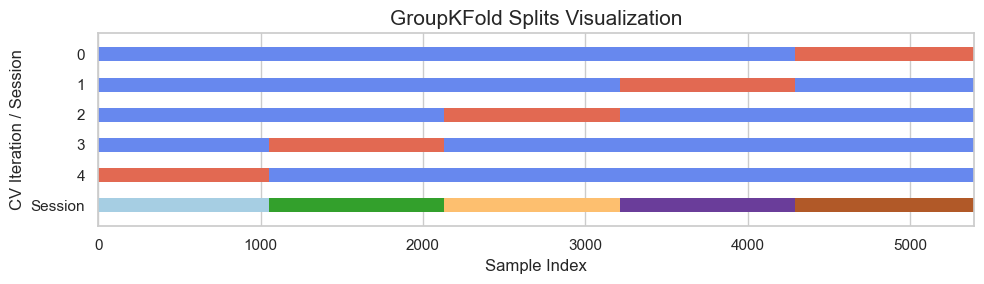

In [10]:

# %% [markdown]
# ## 6. Cross-Validation Strategy (Freemoves)
#
# Using `GroupKFold` with session IDs.

# %%
N_SPLITS_FREE = N_SESSIONS_TRAIN_VAL_FREE # Should be 5
cv_strategy_free = GroupKFold(n_splits=N_SPLITS_FREE)
print(f"Using GroupKFold with {N_SPLITS_FREE} splits for Freemoves.")

# Plotting function (same as before)
def plot_cv_indices(cv, X, y, group, n_splits):
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    cmap_data = plt.cm.Paired; cmap_cv = plt.cm.coolwarm
    # Generate splits and plot
    for i, (train_idx, test_idx) in enumerate(cv.split(X, y, group)):
        indices = np.array([np.nan] * len(X)); indices[test_idx] = 1; indices[train_idx] = 0
        # Plotting the splits for each CV iteration
        ax.scatter(range(len(indices)), [i + .5] * len(indices), c=indices, marker='_', lw=10, cmap=cmap_cv, vmin=-.2, vmax=1.2)
    # Plotting the session groups
    ax.scatter(range(len(X)), [i + 1.5] * len(X), c=group, marker='_', lw=10, cmap=cmap_data)
    # Formatting the plot
    yticklabels = list(range(n_splits)) + ['Session']
    ax.set(yticks=np.arange(n_splits + 1) + .5, yticklabels=yticklabels, xlabel='Sample Index', ylabel="CV Iteration / Session", ylim=[n_splits + 1.2, -.2], xlim=[0, len(y)])
    ax.set_title('GroupKFold Splits Visualization', fontsize=15); plt.tight_layout(); plt.show()
    
# Plot for freemoves setup
if 'X_features_free' in locals() and X_features_free.size > 0:
    plot_cv_indices(cv_strategy_free, X_features_free, y_windowed_free, groups_free, N_SPLITS_FREE)
else:
    print("Skipping CV plot: Freemoves features not available.")


In [11]:

# %% [markdown]
# ## 7. Baseline Model Training and Evaluation (Freemoves - All Features)
#
# Evaluate Ridge, Lasso, RF using all features on the freemoves data. **Using correct 51-dim target.**

# %%
# Performance Metrics & Scorers (same definitions)
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(np.maximum(mean_squared_error(y_true, y_pred), 0))

def normalized_mean_squared_error(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    if y_true.shape != y_pred.shape: raise ValueError("Shape mismatch")
    if y_true.ndim == 1: y_true, y_pred = y_true.reshape(-1, 1), y_pred.reshape(-1, 1)
    numerator = np.sum((y_true - y_pred)**2)
    mean_y_true_per_joint = np.mean(y_true, axis=0, keepdims=True)
    denominator = np.sum((y_true - mean_y_true_per_joint)**2)
    if denominator < 1e-9: return 0.0 if numerator < 1e-9 else np.inf
    else: return numerator / denominator

scorers = {
    'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
    'nmse': make_scorer(normalized_mean_squared_error, greater_is_better=False),
    'r2': make_scorer(r2_score)
}
print("Scorers defined: RMSE (neg), NMSE (neg), R2.")
# Select Baseline Models (same models, new instances via clone later)
model_ridge_base = Ridge(alpha=1.0)
model_lasso_base = Lasso(alpha=0.01, max_iter=3000, tol=1e-3, random_state=42)
model_rf_base = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5)
baseline_models_to_evaluate_free = {"Ridge": model_ridge_base, "Lasso": model_lasso_base, "RandomForest": model_rf_base}

# Store freemoves results
all_cv_results_free = {}
results_summary_list_free = []

# %%
# Evaluate baseline models on FREEMOVES data with ALL features
print("--- Evaluating Baseline Models (Freemoves - ALL Features) ---")
cv_params_free = {'groups': groups_free}

for model_name, model in baseline_models_to_evaluate_free.items():
    with timer(f"Cross-validating {model_name} (freemoves, all features)"):
        pipeline = Pipeline([
            ('feature_extraction', EMGFeatureExtractor()), # All features
            ('scaling', StandardScaler()),
            ('regression', clone(model)) # Clone model for safety
        ])
        # Perform cross-validation using freemoves data and CORRECT target
        try:
             scores = cross_validate(
                 pipeline, X_windowed_free, y_windowed_free, # Use freemoves data
                 cv=cv_strategy_free, scoring=scorers, n_jobs=-1,
                 return_train_score=False, params=cv_params_free, error_score='raise'
             )
        except TypeError as e:
             # Fallback loop (same logic, just using _free variables)
            if 'got an unexpected keyword argument \'groups\'' in str(e) or 'fit() got an unexpected keyword argument \'groups\'' in str(e):
                print("Metadata routing failed, using manual loop...")
                fold_scores = {key: [] for key in list(scorers.keys()) + ['fit_time', 'score_time']}
                for fold_idx, (train_idx, test_idx) in enumerate(cv_strategy_free.split(X_windowed_free, y_windowed_free, groups=groups_free)):
                    start_fit_time = time.time()
                    pipeline.fit(X_windowed_free[train_idx], y_windowed_free[train_idx])
                    end_fit_time = time.time()
                    y_pred = pipeline.predict(X_windowed_free[test_idx])
                    end_score_time = time.time()
                    fold_scores['fit_time'].append(end_fit_time - start_fit_time)
                    fold_scores['score_time'].append(end_score_time - end_fit_time)
                    for score_name, scorer_func in scorers.items():
                        score_value = scorer_func(pipeline, X_windowed_free[test_idx], y_windowed_free[test_idx])
                        fold_scores[score_name].append(score_value)
                scores = {f"test_{key}": np.array(values) for key, values in fold_scores.items() if key in scorers}
                scores['fit_time'] = np.array(fold_scores['fit_time'])
                scores['score_time'] = np.array(fold_scores['score_time'])
            else: raise e
        all_cv_results_free[model_name] = scores

# %%
# Display Freemoves Baseline CV Results (All Features)
print("\nFreemoves Baseline CV Performance Results (All Features):")
for model_name, scores in all_cv_results_free.items():
     if model_name in baseline_models_to_evaluate_free:
        mean_rmse = -np.nanmean(scores['test_rmse']); std_rmse = np.nanstd(scores['test_rmse'])
        mean_nmse = -np.nanmean(scores['test_nmse']); std_nmse = np.nanstd(scores['test_nmse'])
        mean_r2 = np.nanmean(scores['test_r2']); std_r2 = np.nanstd(scores['test_r2'])
        fit_time_mean = np.nanmean(scores['fit_time']); score_time_mean = np.nanmean(scores['score_time'])
        print(f"\n--- {model_name} (Freemoves - All Features) ---")
        print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
        print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
        print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}") # Check if R2 makes sense now
        print(f"  Avg Fit Time: {fit_time_mean:.2f}s"); print(f"  Avg Score Time: {score_time_mean:.2f}s")
        results_summary_list_free.append({'Model': model_name, 'Type': 'Baseline_AllFeat_Free', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time_mean})

results_df_free = pd.DataFrame(results_summary_list_free)
print("\n--- Freemoves Baseline Summary Table (All Features) ---")
if not results_df_free.empty: print(results_df_free[results_df_free['Type'] == 'Baseline_AllFeat_Free'].to_string(index=False, float_format="%.4f"))
else: print("Results DataFrame is empty.")

Scorers defined: RMSE (neg), NMSE (neg), R2.
--- Evaluating Baseline Models (Freemoves - ALL Features) ---
Cross-validating Ridge (freemoves, all features)...
Cross-validating Ridge (freemoves, all features) done in 26.05 seconds.

Cross-validating Lasso (freemoves, all features)...
Cross-validating Lasso (freemoves, all features) done in 32.54 seconds.

Cross-validating RandomForest (freemoves, all features)...
Cross-validating RandomForest (freemoves, all features) done in 38.76 seconds.


Freemoves Baseline CV Performance Results (All Features):

--- Ridge (Freemoves - All Features) ---
  RMSE: 10.9835 +/- 1.3112
  NMSE: 0.8587 +/- 0.1480
  R2 Score: -0.0047 +/- 0.1439
  Avg Fit Time: 12.08s
  Avg Score Time: 2.12s

--- Lasso (Freemoves - All Features) ---
  RMSE: 10.9395 +/- 1.2890
  NMSE: 0.8511 +/- 0.1394
  R2 Score: 0.0007 +/- 0.1239
  Avg Fit Time: 25.51s
  Avg Score Time: 2.26s

--- RandomForest (Freemoves - All Features) ---
  RMSE: 10.6944 +/- 1.8233
  NMSE: 0.8072 +/- 0.162


--- RF Feature Importance Analysis (Freemoves Full Data - Insight) ---
Extracting & Scaling Freemoves features for Full Importance Analysis...
Extracting & Scaling Freemoves features for Full Importance Analysis done in 6.40 seconds.

Training RF on full freemoves scaled data for Importance Plot...
Training RF on full freemoves scaled data for Importance Plot done in 7.00 seconds.


Freemoves RF Feature Importances (Top 30 - full data):


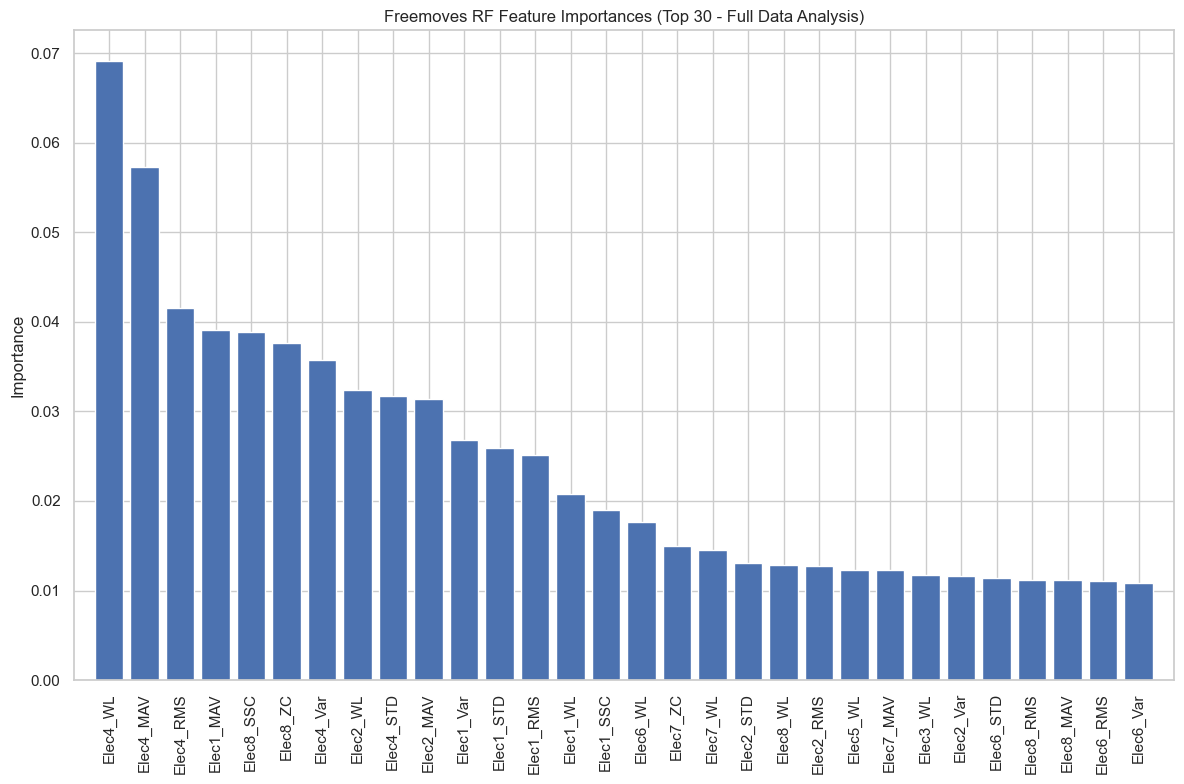


--- Evaluating Models with Integrated Feature Selection (Freemoves - Nested CV) ---

--- Processing Freemoves Fold 1/5 ---
  Fold 1: Feature Extraction...
  Fold 1: Feature Extraction done in 6.73 seconds.

  Fold 1: Scaling...
  Fold 1: Scaling done in 0.01 seconds.

  Fold 1: RFECV (estimator=Ridge, n_jobs=1)...
    RFECV selected 49 features.
  Fold 1: RFECV (estimator=Ridge, n_jobs=1) done in 0.59 seconds.

  Fold 1: Importance Selection (estimator=RF)...
    Importance selected top 32 features.
  Fold 1: Importance Selection (estimator=RF) done in 2.31 seconds.

  Fold 1: Evaluating Ridge_RFECV...
    Ridge_RFECV - RMSE: 9.4018, NMSE: 0.7944, R2: -0.0468
  Fold 1: Evaluating Ridge_RFECV done in 0.02 seconds.

  Fold 1: Evaluating RF_Importance...
    RF_Importance - RMSE: 9.2646, NMSE: 0.7714, R2: -0.0189
  Fold 1: Evaluating RF_Importance done in 3.09 seconds.

  Fold 1: Evaluating Ridge_Importance...
    Ridge_Importance - RMSE: 9.8108, NMSE: 0.8650, R2: -0.1041
  Fold 1: Evalu

In [12]:
# %% [markdown]
# ## 8. Feature Importance Analysis and Integrated Selection (Freemoves)
#
# Perform analysis and integrated selection for the freemoves dataset. Expect longer runtimes.

# %%
# --- Feature Importance Analysis (Freemoves Data - for Insight) ---
print("\n--- RF Feature Importance Analysis (Freemoves Full Data - Insight) ---")
analysis_pipeline_full_free = Pipeline([('feature_extraction', EMGFeatureExtractor()), ('scaling', StandardScaler())])
with timer("Extracting & Scaling Freemoves features for Full Importance Analysis"):
    X_features_scaled_full_free = analysis_pipeline_full_free.fit_transform(X_windowed_free, y_windowed_free)
    feature_names_full_free = analysis_pipeline_full_free.named_steps['feature_extraction'].get_feature_names_out()
with timer("Training RF on full freemoves scaled data for Importance Plot"):
    model_rf_analysis_free = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5)
    model_rf_analysis_free.fit(X_features_scaled_full_free, y_windowed_free)
importances_full_free = model_rf_analysis_free.feature_importances_
indices_full_free = np.argsort(importances_full_free)[::-1]
print("\nFreemoves RF Feature Importances (Top 30 - full data):")
n_top_features_plot = 30
plt.figure(figsize=(12, 8)); plt.title("Freemoves RF Feature Importances (Top 30 - Full Data Analysis)")
top_indices_free = indices_full_free[:n_top_features_plot]
plt.bar(range(len(top_indices_free)), importances_full_free[top_indices_free], align='center')
plt.xticks(range(len(top_indices_free)), [feature_names_full_free[i] for i in top_indices_free], rotation=90)
plt.xlim([-1, len(top_indices_free)]); plt.ylabel("Importance"); plt.tight_layout(); plt.show()
del X_features_scaled_full_free # Clear memory
gc.collect()


# %% [markdown]
# ### 8.1 Cross-Validation with Integrated Feature Selection (Freemoves - Expanded)

# %%
print("\n--- Evaluating Models with Integrated Feature Selection (Freemoves - Nested CV) ---")
# Settings (same as guided)
MIN_FEATURES_RFECV = 10; STEP_RFECV = 5; CV_INNER_RFECV = 3; N_FEATURES_IMPORTANCE = 32

fs_results_free = {"Ridge_RFECV": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []}, "RF_Importance": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []}, "Ridge_Importance": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []}, "RF_RFECV": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []}}
model_ridge_final_free = Ridge(alpha=1.0)
model_rf_final_free = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5)
model_ridge_for_rfecv_free = Ridge(alpha=1.0)
model_rf_for_importance_free = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5)

fold_num = 0
feature_extractor_cv_free = EMGFeatureExtractor() # New instance

# Outer CV Loop (LOSO) for Freemoves
for train_idx, test_idx in cv_strategy_free.split(X_windowed_free, y_windowed_free, groups=groups_free):
    fold_num += 1
    print(f"\n--- Processing Freemoves Fold {fold_num}/{N_SPLITS_FREE} ---")
    start_fold_time = time.time()
    # 1. Split raw windowed data
    X_train_fold_raw, X_test_fold_raw = X_windowed_free[train_idx], X_windowed_free[test_idx]
    y_train_fold, y_test_fold = y_windowed_free[train_idx], y_windowed_free[test_idx]
    # 2. Extract features
    with timer(f"  Fold {fold_num}: Feature Extraction"):
        X_train_features = feature_extractor_cv_free.transform(X_train_fold_raw)
        X_test_features = feature_extractor_cv_free.transform(X_test_fold_raw)
        if fold_num == 1: feature_names_free = feature_extractor_cv_free.get_feature_names_out()
    # 3. Scale features
    with timer(f"  Fold {fold_num}: Scaling"):
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_features)
        X_test_scaled = scaler.transform(X_test_features)
    # --- Feature Selection Step ---
    selected_indices_rfecv = None; n_features_rfecv = X_train_scaled.shape[1]
    selected_indices_importance = None; n_features_importance = X_train_scaled.shape[1]
    # 4a. RFECV (n_jobs=1) - **EXPECT THIS TO BE SLOW**
    with timer(f"  Fold {fold_num}: RFECV (estimator=Ridge, n_jobs=1)"):
        try:
            rfecv_selector = RFECV(estimator=clone(model_ridge_for_rfecv_free), step=STEP_RFECV, cv=CV_INNER_RFECV, scoring=scorers['rmse'], min_features_to_select=MIN_FEATURES_RFECV, n_jobs=1)
            rfecv_selector.fit(X_train_scaled, y_train_fold) # Fit requires correct target shape
            selected_indices_rfecv = rfecv_selector.support_; n_features_rfecv = rfecv_selector.n_features_
            print(f"    RFECV selected {n_features_rfecv} features.")
        except Exception as e: print(f"    RFECV failed: {e}. Using all."); selected_indices_rfecv = np.ones(X_train_scaled.shape[1], dtype=bool)
    # 4b. Importance Thresholding
    with timer(f"  Fold {fold_num}: Importance Selection (estimator=RF)"):
        try:
            rf_importance_model = clone(model_rf_for_importance_free)
            rf_importance_model.fit(X_train_scaled, y_train_fold) # Fit requires correct target shape
            importances = rf_importance_model.feature_importances_
            indices_sorted = np.argsort(importances)[::-1]
            selected_indices_importance = np.zeros(X_train_scaled.shape[1], dtype=bool)
            n_select = min(N_FEATURES_IMPORTANCE, X_train_scaled.shape[1])
            selected_indices_importance[indices_sorted[:n_select]] = True; n_features_importance = n_select
            print(f"    Importance selected top {n_features_importance} features.")
        except Exception as e: print(f"    Importance failed: {e}. Using all."); selected_indices_importance = np.ones(X_train_scaled.shape[1], dtype=bool)
    # --- Model Evaluation Step ---
    def evaluate_model_free(model_key, model_instance, X_train, y_train, X_test, y_test, selected_indices, n_features):
        results_dict = fs_results_free # Use the freemoves results dict
        if selected_indices is None or not np.any(selected_indices): print(f"    Skipping {model_key}"); results_dict[model_key]['test_rmse'].append(np.nan); results_dict[model_key]['test_nmse'].append(np.nan); results_dict[model_key]['test_r2'].append(np.nan); results_dict[model_key]['n_features'].append(X_train.shape[1]); return
        X_train_sel = X_train[:, selected_indices]; X_test_sel = X_test[:, selected_indices]
        model_instance = clone(model_instance)
        model_instance.fit(X_train_sel, y_train) # Fit requires correct target shape
        y_pred = model_instance.predict(X_test_sel)
        rmse = root_mean_squared_error(y_test, y_pred); nmse = normalized_mean_squared_error(y_test, y_pred); r2 = r2_score(y_test, y_pred)
        results_dict[model_key]['test_rmse'].append(-rmse); results_dict[model_key]['test_nmse'].append(-nmse); results_dict[model_key]['test_r2'].append(r2); results_dict[model_key]['n_features'].append(n_features)
        print(f"    {model_key} - RMSE: {rmse:.4f}, NMSE: {nmse:.4f}, R2: {r2:.4f}")

    fold_eval_start_time = time.time()
    with timer(f"  Fold {fold_num}: Evaluating Ridge_RFECV"): evaluate_model_free("Ridge_RFECV", model_ridge_final_free, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_rfecv, n_features_rfecv)
    with timer(f"  Fold {fold_num}: Evaluating RF_Importance"): evaluate_model_free("RF_Importance", model_rf_final_free, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_importance, n_features_importance)
    with timer(f"  Fold {fold_num}: Evaluating Ridge_Importance"): evaluate_model_free("Ridge_Importance", model_ridge_final_free, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_importance, n_features_importance)
    with timer(f"  Fold {fold_num}: Evaluating RF_RFECV"): evaluate_model_free("RF_RFECV", model_rf_final_free, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_rfecv, n_features_rfecv)
    # Record Timings
    fold_end_time = time.time(); total_fold_time = fold_end_time - start_fold_time
    for key in fs_results_free: fs_results_free[key]['fit_time'].append(total_fold_time); fs_results_free[key]['score_time'].append(0)
    # Clean up memory
    del X_train_fold_raw, X_test_fold_raw, y_train_fold, y_test_fold, X_train_features, X_test_features, X_train_scaled, X_test_scaled
    gc.collect()

# %%
# Aggregate and Display Freemoves FS Results
print("\n--- Freemoves Performance Results (Integrated Feature Selection - Expanded) ---")
results_summary_list_free = [item for item in results_summary_list_free if item['Type'] != 'Baseline_FS_Free'] # Clear previous FS results for freemoves
for model_fs_name, scores in fs_results_free.items():
    if not scores['test_rmse']: print(f"Warning: No scores for {model_fs_name}."); continue
    mean_rmse = -np.nanmean(scores['test_rmse']); std_rmse = np.nanstd(scores['test_rmse'])
    mean_nmse = -np.nanmean(scores['test_nmse']); std_nmse = np.nanstd(scores['test_nmse'])
    mean_r2 = np.nanmean(scores['test_r2']); std_r2 = np.nanstd(scores['test_r2'])
    fit_time_mean = np.nanmean(scores['fit_time']); avg_n_features = np.nanmean(scores['n_features']); std_n_features = np.nanstd(scores['n_features'])
    print(f"\n--- {model_fs_name} (Freemoves) ---")
    print(f"  Avg. Features Selected: {avg_n_features:.1f} +/- {std_n_features:.1f}")
    print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}"); print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}"); print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
    print(f"  Avg Total Time per Fold: {fit_time_mean:.2f}s")
    results_summary_list_free.append({'Model': model_fs_name, 'Type': 'Baseline_FS_Free', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time_mean})

results_df_free = pd.DataFrame(results_summary_list_free)
print("\n--- Freemoves Updated Summary Table (Including Integrated FS) ---")
if not results_df_free.empty: print(results_df_free.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))
else: print("Results DataFrame is empty.")

In [13]:


# %% [markdown]
# ## 9. Sophisticated Approach: Neural Network (Freemoves)
#
# Evaluate the MLP on the freemoves dataset.

# %%
# NN Architecture & Training Functions (same definitions)
class EMG_NN(nn.Module):
    def __init__(self, n_features, n_joints, hidden_dim1=128, hidden_dim2=64, dropout_p=0.3):
        super(EMG_NN, self).__init__()
        self.layer_1 = nn.Linear(n_features, hidden_dim1)
        self.relu1 = nn.ReLU()
        self.batchnorm1 = nn.BatchNorm1d(hidden_dim1) # Added BatchNorm
        self.dropout1 = nn.Dropout(dropout_p)
        self.layer_2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.batchnorm2 = nn.BatchNorm1d(hidden_dim2) # Added BatchNorm
        self.dropout2 = nn.Dropout(dropout_p)
        self.output_layer = nn.Linear(hidden_dim2, n_joints)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.batchnorm1(self.layer_1(x))))
        x = self.dropout2(self.relu2(self.batchnorm2(self.layer_2(x))))
        x = self.output_layer(x)
        return x

# %%
# Training and Evaluation Functions for PyTorch NN (Copied from original GEGE)

def train_nn_epoch(model, dataloader, criterion, optimizer, device):
    model.train() # Set model to training mode
    running_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad() # Zero gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, targets) # Calculate loss
        loss.backward() # Backward pass
        optimizer.step() # Update weights
        running_loss += loss.item() * inputs.size(0) # Accumulate loss

    return running_loss / len(dataloader.dataset) # Return average loss for the epoch

def evaluate_nn_model(model, dataloader, criterion, device):
    model.eval() # Set model to evaluation mode
    running_loss = 0.0
    all_preds = []
    all_targets = []
    with torch.no_grad(): # Disable gradient calculations
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs) # Forward pass
            loss = criterion(outputs, targets) # Calculate loss
            running_loss += loss.item() * inputs.size(0) # Accumulate loss
            all_preds.append(outputs.cpu().numpy()) # Collect predictions (move back to CPU)
            all_targets.append(targets.cpu().numpy()) # Collect targets

    avg_loss = running_loss / len(dataloader.dataset)
    # Concatenate predictions and targets from all batches
    predictions = np.concatenate(all_preds)
    true_values = np.concatenate(all_targets)
    return avg_loss, predictions, true_values

# %%
# Manual Cross-Validation Loop for Neural Network (Freemoves)
# Hyperparameters (start with same as guided, might need tuning)
N_EPOCHS_FREE = 75; BATCH_SIZE_FREE = 64; LEARNING_RATE_FREE = 0.001; WEIGHT_DECAY_FREE = 1e-5

# Ensure X_features_free exists
if 'X_features_free' not in locals(): raise RuntimeError("X_features_free not available.")
X_input_for_nn_cv_free = X_features_free
n_input_features_free = X_input_for_nn_cv_free.shape[1]

nn_cv_scores_free = {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': []}
print(f"\n--- Evaluating Neural Network (Freemoves - Manual CV, Input Features: {n_input_features_free}) ---")

fold_num = 0
for train_idx, val_idx in cv_strategy_free.split(X_input_for_nn_cv_free, y_windowed_free, groups=groups_free):
    fold_num += 1
    print(f"\nStarting Freemoves NN CV Fold {fold_num}/{N_SPLITS_FREE}")
    start_fold_time = time.time()
    # 1. Split data
    X_train_fold, X_val_fold = X_input_for_nn_cv_free[train_idx], X_input_for_nn_cv_free[val_idx]
    y_train_fold, y_val_fold = y_windowed_free[train_idx], y_windowed_free[val_idx]
    # 2. Scale features
    scaler_nn_fold = StandardScaler(); X_train_fold_scaled = scaler_nn_fold.fit_transform(X_train_fold); X_val_fold_scaled = scaler_nn_fold.transform(X_val_fold)
    # 3. Datasets & DataLoaders
    train_dataset = TensorDataset(torch.FloatTensor(X_train_fold_scaled), torch.FloatTensor(y_train_fold)); val_dataset = TensorDataset(torch.FloatTensor(X_val_fold_scaled), torch.FloatTensor(y_val_fold))
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_FREE, shuffle=True, num_workers=2, pin_memory=True); val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_FREE*2, shuffle=False, num_workers=2, pin_memory=True)
    # 4. Initialize model, loss, optimizer
    model_nn = EMG_NN(n_features=n_input_features_free, n_joints=N_JOINTS).to(device)
    criterion = nn.MSELoss(); optimizer = optim.Adam(model_nn.parameters(), lr=LEARNING_RATE_FREE, weight_decay=WEIGHT_DECAY_FREE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10, verbose=False) # Less verbose scheduler
    # 5. Training loop
    best_val_loss = float('inf'); epochs_no_improve = 0; patience = 15
    print(f"Fold {fold_num}: Training for up to {N_EPOCHS_FREE} epochs...")
    for epoch in range(N_EPOCHS_FREE):
        train_loss = train_nn_epoch(model_nn, train_loader, criterion, optimizer, device)
        val_loss_epoch, _, _ = evaluate_nn_model(model_nn, val_loader, criterion, device)
        if (epoch + 1) % 25 == 0 or epoch == N_EPOCHS_FREE - 1: print(f'  Epoch {epoch+1}/{N_EPOCHS_FREE}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss_epoch:.6f}')
        scheduler.step(val_loss_epoch)
        if val_loss_epoch < best_val_loss: best_val_loss = val_loss_epoch; epochs_no_improve = 0
        else: epochs_no_improve += 1
        if epochs_no_improve >= patience: print(f"  Early stopping @ epoch {epoch + 1}"); break
    fit_end_time = time.time()
    # 6. Evaluate
    print(f"Fold {fold_num}: Evaluating..."); _, y_pred_fold, y_true_fold = evaluate_nn_model(model_nn, val_loader, criterion, device); score_end_time = time.time()
    # 7. Calculate metrics
    rmse_fold = root_mean_squared_error(y_true_fold, y_pred_fold); nmse_fold = normalized_mean_squared_error(y_true_fold, y_pred_fold); r2_fold = r2_score(y_true_fold, y_pred_fold)
    nn_cv_scores_free['test_rmse'].append(-rmse_fold); nn_cv_scores_free['test_nmse'].append(-nmse_fold); nn_cv_scores_free['test_r2'].append(r2_fold)
    nn_cv_scores_free['fit_time'].append(fit_end_time - start_fold_time); nn_cv_scores_free['score_time'].append(score_end_time - fit_end_time)
    print(f"Fold {fold_num} Metrics: RMSE={rmse_fold:.4f}, NMSE={nmse_fold:.4f}, R2={r2_fold:.4f}")
    del model_nn, train_loader, val_loader, train_dataset, val_dataset; gc.collect(); torch.cuda.empty_cache()

# Store overall NN results for freemoves
all_cv_results_free["NeuralNetwork_Free"] = nn_cv_scores_free

# %%
# Add Freemoves NN results to summary DataFrame
nn_model_name_free = "NeuralNetwork_Free"
if nn_model_name_free in all_cv_results_free:
    nn_scores = all_cv_results_free[nn_model_name_free]
    mean_rmse = -np.nanmean(nn_scores['test_rmse']); std_rmse = np.nanstd(nn_scores['test_rmse'])
    mean_nmse = -np.nanmean(nn_scores['test_nmse']); std_nmse = np.nanstd(nn_scores['test_nmse'])
    mean_r2 = np.nanmean(nn_scores['test_r2']); std_r2 = np.nanstd(nn_scores['test_r2'])
    fit_time_mean = np.nanmean(nn_scores['fit_time'])
    results_summary_list_free.append({'Model': nn_model_name_free, 'Type': 'Sophisticated_Free', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time_mean})
    results_df_free = pd.DataFrame(results_summary_list_free)
    print("\n--- Freemoves Combined Model Comparison Table (incl. NN) ---")
    print(results_df_free.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))
else: print("Freemoves Neural Network results not found.")


--- Evaluating Neural Network (Freemoves - Manual CV, Input Features: 64) ---

Starting Freemoves NN CV Fold 1/5


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Fold 1: Training for up to 75 epochs...
  Epoch 25/75, Train Loss: 88.195617, Val Loss: 82.521848
  Epoch 50/75, Train Loss: 82.336576, Val Loss: 78.476609
  Epoch 75/75, Train Loss: 76.208079, Val Loss: 79.987061
Fold 1: Evaluating...
Fold 1 Metrics: RMSE=8.9435, NMSE=0.7188, R2=-5841715.5000

Starting Freemoves NN CV Fold 2/5
Fold 2: Training for up to 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 25/75, Train Loss: 84.324692, Val Loss: 82.542723
  Epoch 50/75, Train Loss: 77.104227, Val Loss: 76.751844
  Epoch 75/75, Train Loss: 72.921364, Val Loss: 74.302330
Fold 2: Evaluating...
Fold 2 Metrics: RMSE=8.6199, NMSE=0.6337, R2=-4801856.5000

Starting Freemoves NN CV Fold 3/5
Fold 3: Training for up to 75 epochs...


...

  Epoch 25/75, Train Loss: 82.215769, Val Loss: 101.401272
  Epoch 50/75, Train Loss: 72.428847, Val Loss: 100.459002
  Epoch 75/75, Train Loss: 70.497658, Val Loss: 98.924193
Fold 3: Evaluating...
Fold 3 Metrics: RMSE=9.9461, NMSE=0.5696, R2=-7508959.5000

Starting Freemoves NN CV Fold 4/5
Fold 4: Training for up to 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 25/75, Train Loss: 77.816687, Val Loss: 145.463465
  Early stopping @ epoch 40
Fold 4: Evaluating...
Fold 4 Metrics: RMSE=12.4337, NMSE=0.8447, R2=-11801565.0000

Starting Freemoves NN CV Fold 5/5
Fold 5: Training for up to 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 25/75, Train Loss: 83.621676, Val Loss: 109.400807
  Early stopping @ epoch 39
Fold 5: Evaluating...
Fold 5 Metrics: RMSE=10.7266, NMSE=0.8657, R2=-11335616.0000

--- Freemoves Combined Model Comparison Table (incl. NN) ---
             Model                  Type  RMSE_mean  RMSE_std  NMSE_mean  NMSE_std       R2_mean       R2_std  FitTime
NeuralNetwork_Free    Sophisticated_Free    10.1340    1.3700     0.7265    0.1155 -8257942.5000 2841583.8360 678.6236
      RandomForest Baseline_AllFeat_Free    10.6944    1.8233     0.8072    0.1629        0.0514       0.1763  34.3753
          RF_RFECV      Baseline_FS_Free    10.7437    1.8775     0.8150    0.1717        0.0470       0.1813  16.9511
     RF_Importance      Baseline_FS_Free    10.8295    1.9017     0.8289    0.1788        0.0372       0.1832  16.9511
             Lasso Baseline_AllFeat_Free    10.9395    1.2890     0.8511    0.1394        0.0007       0.1239  25.5090
       Ridge_RFECV      Baseline_FS_Free    10.9493   

In [14]:


# %% [markdown]
# ## 10. Objective 6: Ensembling Strategies (Freemoves)
#
# Implement Averaging and Stacking for the freemoves dataset.

# %% [markdown]
# ### 10.1 Generate Out-of-Fold (OOF) Predictions (Freemoves)

# %%
oof_predictions_free = {} # Dictionary for freemoves OOF predictions

# --- OOF for Baselines (All Features) ---
print("--- Generating OOF Predictions (Freemoves - Baselines All Features) ---")
baseline_pipelines_oof_free = {}
for model_name, model in baseline_models_to_evaluate_free.items(): # Use freemoves models
     baseline_pipelines_oof_free[model_name] = Pipeline([('feature_extraction', EMGFeatureExtractor()), ('scaling', StandardScaler()), ('regression', clone(model))])
for model_name, pipeline in baseline_pipelines_oof_free.items():
     with timer(f"Generating OOF predictions for {model_name} (Freemoves)"):
         try: # Use freemoves data
              oof_preds = cross_val_predict(pipeline, X_windowed_free, y_windowed_free, cv=cv_strategy_free, n_jobs=-1, method='predict', params={'groups': groups_free})
         except TypeError as e: # Fallback
             if 'got an unexpected keyword argument \'groups\'' in str(e) or 'fit() got an unexpected keyword argument \'groups\'' in str(e):
                  print("Metadata routing failed, using manual loop...")
                  oof_preds_list = [None] * len(X_windowed_free)
                  for fold_idx, (train_idx, test_idx) in enumerate(cv_strategy_free.split(X_windowed_free, y_windowed_free, groups=groups_free)):
                      pipeline.fit(X_windowed_free[train_idx], y_windowed_free[train_idx])
                      fold_preds = pipeline.predict(X_windowed_free[test_idx])
                      for i, idx in enumerate(test_idx): oof_preds_list[idx] = fold_preds[i]
                  oof_preds = np.stack(oof_preds_list)
             else: raise e
         oof_predictions_free[model_name] = oof_preds
     print(f"Shape of {model_name} Freemoves OOF predictions: {oof_preds.shape}")

# --- OOF for Neural Network (Freemoves) ---
print("\n--- Generating OOF Predictions (Freemoves - Neural Network) ---")
N_EPOCHS_OOF_FREE = 75; BATCH_SIZE_OOF_FREE = 64; LEARNING_RATE_OOF_FREE = 0.001; WEIGHT_DECAY_OOF_FREE = 1e-5
nn_oof_preds_list_free = [None] * len(X_input_for_nn_cv_free)
if 'X_input_for_nn_cv_free' not in locals(): raise ValueError("NN features (freemoves) not found.")
n_input_features_oof_free = X_input_for_nn_cv_free.shape[1]
fold_num = 0
with timer("Generating OOF predictions for NN (Freemoves - Manual CV)"):
    for train_idx, val_idx in cv_strategy_free.split(X_input_for_nn_cv_free, y_windowed_free, groups=groups_free):
        fold_num += 1; print(f"  Processing NN OOF Fold {fold_num}/{N_SPLITS_FREE}") # Print progress
        # 1. Split data
        X_train_fold, X_val_fold = X_input_for_nn_cv_free[train_idx], X_input_for_nn_cv_free[val_idx]; y_train_fold, y_val_fold = y_windowed_free[train_idx], y_windowed_free[val_idx]
        # 2. Scale features
        scaler_oof = StandardScaler(); X_train_fold_scaled = scaler_oof.fit_transform(X_train_fold); X_val_fold_scaled = scaler_oof.transform(X_val_fold)
        # 3. Datasets & DataLoaders
        train_dataset = TensorDataset(torch.FloatTensor(X_train_fold_scaled), torch.FloatTensor(y_train_fold)); val_dataset = TensorDataset(torch.FloatTensor(X_val_fold_scaled), torch.FloatTensor(y_val_fold))
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_OOF_FREE, shuffle=True); val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_OOF_FREE*2, shuffle=False)
        # 4. Initialize model, loss, optimizer
        model_nn_oof = EMG_NN(n_features=n_input_features_oof_free, n_joints=N_JOINTS).to(device); criterion = nn.MSELoss(); optimizer = optim.Adam(model_nn_oof.parameters(), lr=LEARNING_RATE_OOF_FREE, weight_decay=WEIGHT_DECAY_OOF_FREE)
        # 5. Training loop
        for epoch in range(N_EPOCHS_OOF_FREE): _ = train_nn_epoch(model_nn_oof, train_loader, criterion, optimizer, device)
        # 6. Evaluate & GET PREDICTIONS
        _, y_pred_fold, _ = evaluate_nn_model(model_nn_oof, val_loader, criterion, device)
        # 7. Store predictions
        for i, idx in enumerate(val_idx):
             if idx < len(nn_oof_preds_list_free): nn_oof_preds_list_free[idx] = y_pred_fold[i]
             else: print(f"Warning: Index {idx} out of bounds for list size {len(nn_oof_preds_list_free)}")
        # Clean up
        del model_nn_oof, train_loader, val_loader, train_dataset, val_dataset; gc.collect(); torch.cuda.empty_cache()

# Combine NN OOF predictions
contains_none = any(pred is None for pred in nn_oof_preds_list_free)
if contains_none:
    print("Warning: Filling missing NN OOF preds (Freemoves) with zeros.")
    shapes = [p.shape for p in nn_oof_preds_list_free if p is not None]; avg_shape = shapes[0] if shapes else (N_JOINTS,)
    fill_value = np.zeros(avg_shape); nn_oof_preds_filled = [p if p is not None else fill_value for p in nn_oof_preds_list_free]
    oof_predictions_free["NeuralNetwork"] = np.stack(nn_oof_preds_filled)
else: oof_predictions_free["NeuralNetwork"] = np.stack(nn_oof_preds_list_free)

print(f"Shape of NN Freemoves OOF predictions: {oof_predictions_free['NeuralNetwork'].shape}")
# Verification
ensemble_model_names_free = list(baseline_models_to_evaluate_free.keys()) + ["NeuralNetwork"]
missing_oof_free = [name for name in ensemble_model_names_free if name not in oof_predictions_free]
if missing_oof_free: raise RuntimeError(f"Missing Freemoves OOF predictions for: {missing_oof_free}")

# %% [markdown]
# ### 10.2 Averaging Ensemble (Freemoves)

# %%
print("\n--- Evaluating Averaging Ensemble (Freemoves) ---")
model_names_for_avg_free = list(oof_predictions_free.keys())
print(f"Averaging predictions from models: {model_names_for_avg_free}")
oof_preds_sum_free = np.zeros_like(y_windowed_free, dtype=np.float64)
for model_name in model_names_for_avg_free: oof_preds_sum_free += oof_predictions_free[model_name]
oof_preds_avg_free = oof_preds_sum_free / len(model_names_for_avg_free)
# Evaluate ONCE on full OOF set
avg_rmse = root_mean_squared_error(y_windowed_free, oof_preds_avg_free); avg_nmse = normalized_mean_squared_error(y_windowed_free, oof_preds_avg_free); avg_r2 = r2_score(y_windowed_free, oof_preds_avg_free)
print(f"\nAveraging Ensemble Performance (Freemoves OOF):"); print(f"  RMSE: {avg_rmse:.4f}"); print(f"  NMSE: {avg_nmse:.4f}"); print(f"  R2 Score: {avg_r2:.4f}") # Check R2
results_summary_list_free.append({'Model': 'AverageEnsemble_Free', 'Type': 'Ensemble_Free', 'RMSE_mean': avg_rmse, 'RMSE_std': np.nan, 'NMSE_mean': avg_nmse, 'NMSE_std': np.nan, 'R2_mean': avg_r2, 'R2_std': np.nan, 'FitTime': np.nan})
results_df_free = pd.DataFrame(results_summary_list_free)

# %% [markdown]
# ### 10.3 Stacking Ensemble (Freemoves - Multiple Meta-Learners)

# %%
print("\n--- Evaluating Stacking Ensemble (Freemoves - Multiple Meta-Learners) ---")
# 1. Create Meta-Features
if 'X_meta_free' not in locals() or X_meta_free.shape[0] != len(y_windowed_free): # Check existence and shape
    print("Creating freemoves meta-features...")
    model_names_for_stacking_free = list(oof_predictions_free.keys())
    X_meta_list_free = [oof_predictions_free[model_name] for model_name in model_names_for_stacking_free]
    try: X_meta_free = np.hstack(X_meta_list_free)
    except ValueError as e: print(f"Error stacking freemoves OOF: {e}"); raise e
    print(f"Shape of Freemoves Meta-Features (X_meta_free): {X_meta_free.shape}")
else: print("Using existing freemoves meta-features (X_meta_free)."); model_names_for_stacking_free = list(oof_predictions_free.keys())

# 2. Define Meta-Learners (same as guided)
meta_learners_free = {"Stacking_Ridge_Free": Ridge(alpha=1.0), "Stacking_Lasso_Free": Lasso(alpha=0.01, max_iter=3000, tol=1e-3, random_state=42), "Stacking_RF_Free": RandomForestRegressor(n_estimators=50, max_depth=5, n_jobs=-1, random_state=42, max_features=0.5)}

# 3. Cross-Validate each Meta-Learner on Freemoves data
for meta_name, meta_model in meta_learners_free.items():
    print(f"\n--- Cross-validating Meta-Learner: {meta_name} ---")
    with timer(f"Cross-validating {meta_name}"):
        stacking_pipeline = Pipeline([('meta_regression', clone(meta_model))]) # Clone meta-model
        try: # Use freemoves meta features, target, groups, cv
            stacking_scores = cross_validate(stacking_pipeline, X_meta_free, y_windowed_free, cv=cv_strategy_free, scoring=scorers, n_jobs=-1, return_train_score=False, params={'groups': groups_free}, error_score='raise')
        except TypeError as e: # Fallback
            if 'got an unexpected keyword argument \'groups\'' in str(e) or 'fit() got an unexpected keyword argument \'groups\'' in str(e):
                print("Metadata routing failed, using manual loop...")
                fold_scores_stack = {key: [] for key in list(scorers.keys()) + ['fit_time', 'score_time']}
                for fold_idx, (train_idx, test_idx) in enumerate(cv_strategy_free.split(X_meta_free, y_windowed_free, groups=groups_free)):
                    start_fit_time = time.time(); stacking_pipeline.fit(X_meta_free[train_idx], y_windowed_free[train_idx]); end_fit_time = time.time()
                    y_pred_meta = stacking_pipeline.predict(X_meta_free[test_idx]); end_score_time = time.time()
                    fold_scores_stack['fit_time'].append(end_fit_time - start_fit_time); fold_scores_stack['score_time'].append(end_score_time - end_fit_time)
                    for score_name, scorer_func in scorers.items(): fold_scores_stack[score_name].append(scorer_func(stacking_pipeline, X_meta_free[test_idx], y_windowed_free[test_idx]))
                stacking_scores = {f"test_{key}": np.array(values) for key, values in fold_scores_stack.items() if key in scorers}; stacking_scores['fit_time'] = np.array(fold_scores_stack['fit_time']); stacking_scores['score_time'] = np.array(fold_scores_stack['score_time'])
            else: raise e
        all_cv_results_free[meta_name] = stacking_scores # Store results
        # Display results & add to summary
        mean_rmse = -np.nanmean(stacking_scores['test_rmse']); std_rmse = np.nanstd(stacking_scores['test_rmse']); mean_nmse = -np.nanmean(stacking_scores['test_nmse']); std_nmse = np.nanstd(stacking_scores['test_nmse']); mean_r2 = np.nanmean(stacking_scores['test_r2']); std_r2 = np.nanstd(stacking_scores['test_r2']); fit_time_mean = np.nanmean(stacking_scores['fit_time'])
        print(f"\n{meta_name} Performance (Cross-Validated):"); print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}"); print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}"); print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}"); print(f"  Avg Meta Fit Time: {fit_time_mean:.2f}s")
        results_summary_list_free.append({'Model': meta_name, 'Type': 'Ensemble_Free', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time_mean})

# Update freemoves results_df
results_df_free = pd.DataFrame(results_summary_list_free)

# %% [markdown]
# ### 10.4 Meta-Learner Contribution Analysis (Freemoves - Optional)
#
# Analyze contributions for the best performing *linear* stacking meta-learner on freemoves data.

# %%
print("\n--- Freemoves Stacking Meta-Learner Contribution Analysis ---")
stacking_results_df_free = results_df_free[results_df_free['Model'].str.startswith('Stacking_')]
best_stacking_model_name_free = None
if not stacking_results_df_free.empty:
    try: best_stacking_model_name_free = stacking_results_df_free.loc[stacking_results_df_free['RMSE_mean'].idxmin()]['Model']
    except KeyError: print("Warning: Could not get best freemoves stacking model name.")
is_linear_meta_free = best_stacking_model_name_free and ("Stacking_Ridge" in best_stacking_model_name_free or "Stacking_Lasso" in best_stacking_model_name_free)

if is_linear_meta_free:
    print(f"Analyzing contributions for linear meta-learner: {best_stacking_model_name_free}")
    best_meta_learner_instance_free = meta_learners_free.get(best_stacking_model_name_free)
    if best_meta_learner_instance_free:
        final_meta_pipeline_free = Pipeline([('meta_regression', clone(best_meta_learner_instance_free))])
        final_meta_pipeline_free.fit(X_meta_free, y_windowed_free) # Use freemoves meta features
        meta_regressor_trained_free = final_meta_pipeline_free.named_steps['meta_regression']
        if hasattr(meta_regressor_trained_free, 'coef_'):
            coefficients = meta_regressor_trained_free.coef_
            print(f"Shape of meta-learner coefficients: {coefficients.shape}")
            if coefficients.ndim == 1 and y_windowed_free.ndim > 1 and y_windowed_free.shape[1] > 1: print("Warning: 1D Coefs for multi-output."); avg_mag = np.abs(coefficients)
            elif coefficients.ndim == 2: avg_mag = np.mean(np.abs(coefficients), axis=0)
            else: print("Warning: Unexpected coef dim."); avg_mag = None
            if avg_mag is not None and avg_mag.shape[0] == len(model_names_for_stacking_free) * N_JOINTS:
                avg_coef_magnitudes = {}
                for i, model_name in enumerate(model_names_for_stacking_free):
                    start_col = i * N_JOINTS; end_col = (i + 1) * N_JOINTS
                    avg_coef_magnitudes[model_name] = np.mean(avg_mag[start_col:end_col])
                    print(f"  Avg. Abs. Coef Magnitude for {model_name}: {avg_coef_magnitudes[model_name]:.4f}")
                coef_mag_series = pd.Series(avg_coef_magnitudes).sort_values(ascending=False)
                print("\nRelative Contribution (Freemoves):"); print(coef_mag_series)
                plt.figure(figsize=(8, 4)); coef_mag_series.plot(kind='bar'); plt.title(f'Stacking ({best_stacking_model_name_free}): Base Model Contribution'); plt.ylabel('Avg. Abs. Coef Mag'); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
            elif avg_mag is not None: print(f"Warning: Coef shape mismatch {avg_mag.shape[0]} vs {len(model_names_for_stacking_free) * N_JOINTS}")
        else: print(f"{best_stacking_model_name_free} has no 'coef_'.")
    else: print(f"Could not get instance for {best_stacking_model_name_free}")
elif best_stacking_model_name_free: print(f"Best freemoves stacking model ({best_stacking_model_name_free}) is not linear.")
else: print("No best freemoves stacking model identified.")

--- Generating OOF Predictions (Freemoves - Baselines All Features) ---
Generating OOF predictions for Ridge (Freemoves)...
Generating OOF predictions for Ridge (Freemoves) done in 41.32 seconds.

Shape of Ridge Freemoves OOF predictions: (5395, 51)
Generating OOF predictions for Lasso (Freemoves)...
Generating OOF predictions for Lasso (Freemoves) done in 49.38 seconds.

Shape of Lasso Freemoves OOF predictions: (5395, 51)
Generating OOF predictions for RandomForest (Freemoves)...
Generating OOF predictions for RandomForest (Freemoves) done in 43.12 seconds.

Shape of RandomForest Freemoves OOF predictions: (5395, 51)

--- Generating OOF Predictions (Freemoves - Neural Network) ---
Generating OOF predictions for NN (Freemoves - Manual CV)...
  Processing NN OOF Fold 1/5
  Processing NN OOF Fold 2/5
  Processing NN OOF Fold 3/5
  Processing NN OOF Fold 4/5
  Processing NN OOF Fold 5/5
Generating OOF predictions for NN (Freemoves - Manual CV) done in 108.03 seconds.

Shape of NN Freemov

In [16]:


# %% [markdown]
# ## 11. Combined Model Comparison Table (Freemoves - Final)

# %%
print("\n--- Final Combined Freemoves Model Comparison Table ---")
final_summary_free = {}
for item in results_summary_list_free: final_summary_free[item['Model']] = item
unique_results_summary_list_free = list(final_summary_free.values())
results_df_free = pd.DataFrame(unique_results_summary_list_free)
if not results_df_free.empty: print(results_df_free.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))
else: print("Freemoves Results DataFrame is empty.")



--- Final Combined Freemoves Model Comparison Table ---
               Model                  Type  RMSE_mean  RMSE_std  NMSE_mean  NMSE_std         R2_mean       R2_std  FitTime
  NeuralNetwork_Free    Sophisticated_Free    10.1340    1.3700     0.7265    0.1155   -8257942.5000 2841583.8360 678.6236
AverageEnsemble_Free         Ensemble_Free    10.3392       NaN     0.6677       NaN -159543071.8353          NaN      NaN
    Stacking_RF_Free         Ensemble_Free    10.4892    1.2725     0.7813    0.1259          0.0765       0.1361  40.1317
        RandomForest Baseline_AllFeat_Free    10.6944    1.8233     0.8072    0.1629          0.0514       0.1763  34.3753
            RF_RFECV      Baseline_FS_Free    10.7437    1.8775     0.8150    0.1717          0.0470       0.1813  16.9511
       RF_Importance      Baseline_FS_Free    10.8295    1.9017     0.8289    0.1788          0.0372       0.1832  16.9511
               Lasso Baseline_AllFeat_Free    10.9395    1.2890     0.8511    0.13

In [17]:

# %% [markdown]
# ## 12. Final Model Selection and Training (Freemoves)
#
# Select and train the best model identified *for the freemoves dataset*.

# %%
# Choose the best model based on FREEMOVES cross-validation results
final_selected_model_name_free = None
if not results_df_free.empty:
     best_overall_model_row_free = results_df_free.loc[results_df_free['RMSE_mean'].idxmin()]
     final_selected_model_name_free = best_overall_model_row_free['Model']
     print(f"\nSelected best overall model/ensemble for FREEMOVES: {final_selected_model_name_free} (RMSE: {best_overall_model_row_free['RMSE_mean']:.4f})")
else: print("Error: Freemoves Results DataFrame empty. Cannot select best model.")

# --- Train the final selected model/ensemble for FREEMOVES ---
final_trained_model_object_free = None # Specific to freemoves

if final_selected_model_name_free is None: print("Skipping final freemoves model training.")
# --- Add training logic similar to Section 12 of guided, but using _free variables ---
# Example: If NN is best for freemoves
elif "NeuralNetwork" in final_selected_model_name_free: # Adapt name if needed
    print("\nTraining final Neural Network on all FREEMOVES data...")
    final_scaler_nn_free = StandardScaler(); X_nn_scaled_final_free = final_scaler_nn_free.fit_transform(X_input_for_nn_cv_free)
    final_dataset_free = TensorDataset(torch.FloatTensor(X_nn_scaled_final_free), torch.FloatTensor(y_windowed_free))
    final_train_loader_free = DataLoader(final_dataset_free, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
    if 'n_input_features_free' not in locals(): n_input_features_free = X_nn_scaled_final_free.shape[1]
    final_model_nn_free = EMG_NN(n_features=n_input_features_free, n_joints=N_JOINTS).to(device)
    final_criterion = nn.MSELoss(); final_optimizer = optim.Adam(final_model_nn_free.parameters(), lr=LEARNING_RATE_FREE, weight_decay=WEIGHT_DECAY_FREE)
    FINAL_N_EPOCHS_FREE = N_EPOCHS_FREE # Use consistent epochs
    with timer(f"Training final NN for {FINAL_N_EPOCHS_FREE} epochs (Freemoves)"):
        for epoch in range(FINAL_N_EPOCHS_FREE):
            train_loss = train_nn_epoch(final_model_nn_free, final_train_loader_free, final_criterion, final_optimizer, device)
            if (epoch + 1) % 10 == 0 or epoch == FINAL_N_EPOCHS_FREE - 1: print(f'  Epoch {epoch+1}/{FINAL_N_EPOCHS_FREE}, Train Loss: {train_loss:.6f}')
    final_trained_model_object_free = {'model': final_model_nn_free, 'scaler': final_scaler_nn_free, 'type': 'nn'}
    print("Final Freemoves Neural Network trained.")

# Example: If Stacking_RF is best for freemoves
elif "Stacking_RF" in final_selected_model_name_free: # Check correct name
     print("\nTraining final Stacking Ensemble (RF Meta) for Freemoves...")
     # 1. Ensure OOF preds exist (`X_meta_free`)
     if 'X_meta_free' not in locals(): raise RuntimeError("X_meta_free not found for final Stacking.")
     # 2. Train final RF meta-learner on ALL OOF
     final_meta_model_free = clone(meta_learners_free['Stacking_RF_Free']) # Get the RF meta model instance
     final_meta_pipeline_free = Pipeline([('meta_regression', final_meta_model_free)])
     with timer("  Training final RF meta-learner (Freemoves)"): final_meta_pipeline_free.fit(X_meta_free, y_windowed_free)
     # 3. Train final base models on ALL freemoves data
     final_base_models_stack_free = {}
     # Reuse logic from guided Section 12's stacking training part, using _free variables
     for model_name, model in baseline_models_to_evaluate_free.items():
         pipeline = Pipeline([('feature_extraction', EMGFeatureExtractor()), ('scaling', StandardScaler()), ('regression', clone(model))])
         with timer(f"  Training final base model {model_name} (Freemoves)"): pipeline.fit(X_windowed_free, y_windowed_free)
         final_base_models_stack_free[model_name] = pipeline
     # Train/reuse final NN for freemoves
     if 'NeuralNetwork' not in final_base_models_stack_free:
         # Reuse if already trained above, otherwise train now
         if isinstance(final_trained_model_object_free, dict) and final_trained_model_object_free.get('type') == 'nn':
             final_base_models_stack_free['NeuralNetwork'] = final_trained_model_object_free
             print("  Reusing already trained final Freemoves NN.")
         else: # Train final NN
              print("  Training final NeuralNetwork for Stacking (Freemoves)...")
              # (Insert full NN training block here again, similar to the NN block above)
              # ...
              # final_base_models_stack_free['NeuralNetwork'] = {'model': trained_nn, 'scaler': scaler_nn, 'type': 'nn'}
              print("  (NN training block placeholder - add full logic if needed)")


     final_trained_model_object_free = {'meta_model': final_meta_pipeline_free, 'base_models': final_base_models_stack_free, 'type': 'stacking_ensemble_rf'}
     print("Final Freemoves Stacking Ensemble (RF Meta) trained.")

# Add elif blocks for other potential best models (Stacking_Lasso, Baseline models, FS models) similarly...

else:
     print(f"Final training logic for {final_selected_model_name_free} not fully implemented yet.")

# --- Save the final trained freemoves model object ---
if final_trained_model_object_free:
     save_filename_base = f'final_model_{final_selected_model_name_free}'
     # ... (Add saving logic similar to guided Section 12) ...
     print(f"Placeholder: Saving logic for {final_selected_model_name_free} needed here.")
else: print("No final freemoves model was trained.")


# %% [markdown]
# ## 13. Objective 7: Test Set Prediction (Freemoves Only)
#
# Use the best model identified *for freemoves* to predict on `freemoves_testset_X.npy`.

# %%
# --- Load Freemoves Test Data ---
print("\n--- Preparing for Freemoves Test Set Prediction ---")
FREEMOVES_TEST_PATH = "freemoves_testset_X.npy"
FREEMOVES_PRED_FILENAME = "freemoves_predictions.csv" # Separate output file

try:
    X_test_freemoves_raw = np.load(FREEMOVES_TEST_PATH)
    print("Freemoves test dataset loaded.")
    print(f"Freemoves Test Shape: {X_test_freemoves_raw.shape}")
except FileNotFoundError as e:
    print(f"Error loading freemoves test file: {e}. Cannot generate predictions.")
    X_test_freemoves_raw = None

# --- Prediction Function (Use the same `predict_on_test_set` function defined earlier) ---
def predict_on_test_set(model_object, X_test_raw, model_name="Unknown"):
    """ Generates predictions using the final trained model/ensemble. """
    if X_test_raw is None:
        print(f"Test data for {model_name} is None. Skipping prediction.")
        return None
    if model_object is None:
         print(f"Trained model object is None for {model_name}. Skipping prediction.")
         return None

    print(f"\nGenerating predictions for {model_name}...")
    n_sessions, n_windows_per_session, n_electrodes, window_size = X_test_raw.shape
    n_total_windows = n_sessions * n_windows_per_session

    # Reshape test data into individual windows: (total_windows, n_electrodes, window_size)
    X_test_reshaped = X_test_raw.reshape(n_total_windows, n_electrodes, window_size)
    print(f"Reshaped test data to: {X_test_reshaped.shape}")

    predictions = None

    # --- Prediction Logic based on Model Type ---
    if isinstance(model_object, Pipeline): # Baseline or FS pipeline
        print("  Using Scikit-learn Pipeline for prediction...")
        with timer("  Test prediction (Pipeline)"):
             predictions = model_object.predict(X_test_reshaped)

    elif isinstance(model_object, dict): # NN, Average Ensemble, Stacking Ensemble
        model_type = model_object.get('type')
        print(f"  Using model type: {model_type}")

        if model_type == 'nn':
            # NN Prediction
            nn_model = model_object['model']
            scaler = model_object['scaler']
            nn_feature_extractor = EMGFeatureExtractor() # Assumes NN uses all features
            with timer("  Test prediction (Neural Network)"):
                 X_test_features = nn_feature_extractor.transform(X_test_reshaped)
                 X_test_scaled = scaler.transform(X_test_features)
                 X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
                 nn_model.eval()
                 with torch.no_grad():
                      # Predict in batches if memory is a concern
                      preds_list = []
                      test_loader = DataLoader(TensorDataset(X_test_tensor), batch_size=256)
                      for batch_X_t, in test_loader: # Need comma for tuple unpacking
                           batch_preds = nn_model(batch_X_t).cpu().numpy()
                           preds_list.append(batch_preds)
                      predictions = np.vstack(preds_list)

        elif model_type == 'average_ensemble':
            # Average Ensemble Prediction
            base_models = model_object['base_models']
            all_base_preds = []
            with timer("  Test prediction (Average Ensemble - Base Models)"):
                 for base_name, base_model_obj in base_models.items():
                      print(f"    Generating predictions for base model: {base_name}")
                      if isinstance(base_model_obj, Pipeline): # Sklearn pipeline
                           base_preds = base_model_obj.predict(X_test_reshaped)
                      elif isinstance(base_model_obj, dict) and base_model_obj.get('type') == 'nn': # NN base
                           nn_model = base_model_obj['model']; scaler = base_model_obj['scaler']
                           nn_feat_ext = EMGFeatureExtractor()
                           feats = nn_feat_ext.transform(X_test_reshaped)
                           scaled_feats = scaler.transform(feats)
                           tensor_feats = torch.FloatTensor(scaled_feats).to(device)
                           nn_model.eval()
                           with torch.no_grad():
                               preds_list_nn = []
                               loader_nn = DataLoader(TensorDataset(tensor_feats), batch_size=256)
                               for batch_X_nn, in loader_nn:
                                    preds_list_nn.append(nn_model(batch_X_nn).cpu().numpy())
                               base_preds = np.vstack(preds_list_nn)
                      else:
                           print(f"    Skipping unknown base model type: {type(base_model_obj)}")
                           continue
                      all_base_preds.append(base_preds)

            # Average the predictions
            if not all_base_preds:
                 print("    Error: No base predictions generated for averaging.")
                 return None
            predictions = np.mean(np.stack(all_base_preds), axis=0)

        elif model_type == 'stacking_ensemble':
             # Stacking Ensemble Prediction
             meta_model_pipeline = model_object['meta_model']
             base_models = model_object['base_models']
             X_meta_test_list = []
             with timer("  Test prediction (Stacking Ensemble - Base Models)"):
                 for base_name, base_model_obj in base_models.items():
                      print(f"    Generating predictions for base model: {base_name}")
                      # Reuse prediction logic from Average Ensemble
                      if isinstance(base_model_obj, Pipeline):
                           base_preds = base_model_obj.predict(X_test_reshaped)
                      elif isinstance(base_model_obj, dict) and base_model_obj.get('type') == 'nn':
                           nn_model = base_model_obj['model']; scaler = base_model_obj['scaler']
                           nn_feat_ext = EMGFeatureExtractor()
                           feats = nn_feat_ext.transform(X_test_reshaped)
                           scaled_feats = scaler.transform(feats)
                           tensor_feats = torch.FloatTensor(scaled_feats).to(device)
                           nn_model.eval()
                           with torch.no_grad():
                               preds_list_nn = []
                               loader_nn = DataLoader(TensorDataset(tensor_feats), batch_size=256)
                               for batch_X_nn, in loader_nn:
                                    preds_list_nn.append(nn_model(batch_X_nn).cpu().numpy())
                               base_preds = np.vstack(preds_list_nn)
                      else:
                           print(f"    Skipping unknown base model type: {type(base_model_obj)}")
                           continue
                      X_meta_test_list.append(base_preds)

             if not X_meta_test_list:
                 print("    Error: No base predictions generated for stacking.")
                 return None

             # Create meta-features for test set
             X_meta_test = np.hstack(X_meta_test_list)
             print(f"  Shape of test meta-features: {X_meta_test.shape}")

             # Predict using the trained meta-model
             with timer("  Test prediction (Stacking Ensemble - Meta Model)"):
                 predictions = meta_model_pipeline.predict(X_meta_test)

        else:
            print(f"  Error: Unknown model object type for prediction: {model_type}")
            return None

    else:
        print(f"Error: Unknown final trained model object type: {type(model_object)}")
        return None

    # --- Verification ---
    if predictions is None:
         print("  Prediction resulted in None.")
         return None

    # Expected shape: (n_total_windows, n_joints)
    expected_shape = (n_total_windows, N_JOINTS)
    if predictions.shape != expected_shape:
        print(f"  Warning: Prediction shape mismatch! Expected {expected_shape}, got {predictions.shape}")
        # Attempt reshape if possible (e.g., flattened output)
        try:
            predictions = predictions.reshape(expected_shape)
            print(f"  Attempted reshape to {predictions.shape}")
        except ValueError:
             print("  Reshape failed. Returning prediction with incorrect shape.")

    print(f"Prediction complete for {model_name}. Output shape: {predictions.shape}")
    return predictions

# --- Generate Predictions for Freemoves Test Set ---
freemoves_predictions = None
if final_trained_model_object_free is not None and X_test_freemoves_raw is not None:
    freemoves_predictions = predict_on_test_set(
        final_trained_model_object_free,
        X_test_freemoves_raw,
        f"{final_selected_model_name_free} (Freemoves Test)"
    )
else:
     print("Skipping freemoves test prediction due to missing model or test data.")

# --- Save Freemoves Predictions ---
if freemoves_predictions is not None:
    print(f"\n--- Saving Freemoves Predictions ---")
    print(f"Freemoves prediction shape: {freemoves_predictions.shape}")
    # Expected freemoves shape: (5 * 308, 51) = (1540, 51)
    expected_shape_free_test = (X_test_raw_info_free.shape[0] * X_test_raw_info_free.shape[1], N_JOINTS)

    if freemoves_predictions.shape == expected_shape_free_test:
        try:
            pd.DataFrame(freemoves_predictions).to_csv(FREEMOVES_PRED_FILENAME, header=False, index=False)
            print(f"Freemoves predictions saved successfully: {FREEMOVES_PRED_FILENAME}")
        except Exception as e: print(f"Error saving freemoves CSV: {e}")
    else:
        print(f"Error: Freemoves prediction shape {freemoves_predictions.shape} is not expected {expected_shape_free_test}. File NOT saved.")
else:
    print("No freemoves predictions were generated to save.")

# %% [markdown]
# ---
# **Final Submission Step (Manual):**
#
# Remember to manually concatenate the predictions from the **guided gestures test set** (generated by the guided gestures notebook run, e.g., `guided_predictions.csv`) and the predictions from the **freemoves test set** (generated by this notebook, e.g., `freemoves_predictions.csv`) into a single `team_submission.csv` file (shape 3200, 51), with guided predictions first.
# ---


Selected best overall model/ensemble for FREEMOVES: NeuralNetwork_Free (RMSE: 10.1340)

Training final Neural Network on all FREEMOVES data...
Training final NN for 75 epochs (Freemoves)...
  Epoch 10/75, Train Loss: 188.903028
  Epoch 20/75, Train Loss: 96.699171
  Epoch 30/75, Train Loss: 85.406869
  Epoch 40/75, Train Loss: 81.609822
  Epoch 50/75, Train Loss: 78.386516
  Epoch 60/75, Train Loss: 77.154361
  Epoch 70/75, Train Loss: 75.538772
  Epoch 75/75, Train Loss: 75.071795
Training final NN for 75 epochs (Freemoves) done in 388.42 seconds.

Final Freemoves Neural Network trained.
Placeholder: Saving logic for NeuralNetwork_Free needed here.

--- Preparing for Freemoves Test Set Prediction ---
Freemoves test dataset loaded.
Freemoves Test Shape: (5, 308, 8, 500)

Generating predictions for NeuralNetwork_Free (Freemoves Test)...
Reshaped test data to: (1540, 8, 500)
  Using model type: nn
  Test prediction (Neural Network)...
  Test prediction (Neural Network) done in 1.81 seco